In [2415]:
# Set working directory to notebook dir
os.chdir('J:\\Brainstation\\BS Git\\Tampa_Apollo_AnthropogenicIndex\\notebooks')

In [1166]:
pwd

'J:\\Brainstation\\BS Git\\Tampa_Apollo_AnthropogenicIndex\\notebooks'

In [2416]:
# Load libraries
%run scripts/imports.py
%run scripts/DataDictionary.py

In [1150]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob as glob
import os as os

# 
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows',None)

In [1157]:
modules=sys.modules.keys

In [1158]:
modules

<function dict.keys>

Introduction:<br><br>

Majority of research literature focuses on ecosystem models without forecasting. They generally are either descriptive statistics and other forms of analyses that describe that current state of health.

Primary literature assess the complex interactions between natural and artificial or anthropogenic pressures from the perspective of ecosystem response. Due to the complexity of the interconnecting variables that determine the health of ecosystems, forecasting can be trickier. TBEP is the primary estuarine research and conservation group with multiple affiliations to government and academic institutions. More about their efforts can be found in the Readme file of this repository.

TBEP developed 2 indices, TBBI and TBNI - representing the health of the benthic and nekton components of the Tampa Bay estuarine ecosystem.

The first phase of this study aims to develop another index that approaches ecosystem health from the aspect of anthropogenic factors. As a first iteration, this index will be and aggregate weighted index, leaning on the Passche index framework.

Here, I present the Investigation into the Anthrogenic features, demonstrate through EDA various relationships in the current dataset, introduce basic regression models that characterize features and transformations that ultimately allow for the construction of the weighted index.

The "Nekton" jupyter notebook serves as the main notebook that joins all EDA analyses and base models to the dataset at large and will ultimately be where the weighted model is aggregated.

### functions

In [2417]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

### Loading Data and Formatting Datasets

In [2]:
"""
Using water quality sampling stations to
"""

'\nUsing water quality sampling stations to\n'

In [3]:
os.chdir('J:/Brainstation/BS Git/data/human Imact')

In [4]:
# Middle Tampa Bay Water Quality
mtbwq=pd.read_csv('MTB_WQ.csv',low_memory=False)

In [5]:
hbwq=pd.read_csv('HB_WTQ.csv',low_memory=False)

In [6]:
# Loading in water quality data
# There are 4-5 water bodies that comprise Tampa Bay.
# These 2 data sets are closest in proximmity to the study site.
# Hillsborough Bay (HB)
# Middle Tampa Bay (MTB)

In [7]:
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Actual_Latitude,Actual_Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [8]:
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude_DD,Longitude_DD,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [9]:
mtbwq.isna().sum()

WBodyID                       0
WaterBodyName                 0
DataSource                    0
StationID                     0
StationName                   0
Actual_StationID              0
Actual_Latitude               0
Actual_Longitude              0
DEP_WBID                      0
SampleDate                    0
ActivityDepth             47806
DepthUnits                    0
Parameter                     0
Characteristic             5507
Sample_Fraction          505439
Result_Value                  0
Result_Unit              102440
QACode                   449145
Result_Comment           501969
Original_Result_Value    153389
Original_Result_Unit     167747
dtype: int64

In [10]:
hbwq.isna().sum()

DataSourceName             0
DataSourceCode             0
StationID                  0
ActualStationID      1048575
Latitude_DD                0
Longitude_DD               0
SampleDate                 0
SampleTime                 0
ActivityDepth         766156
ActivityDepthUnit     758436
Characteristic        748461
ResultValue              985
ResultUnit            786325
ValueQualifier       1005190
ResultComment        1035222
WaterbodyID                0
WaterbodyName              0
dtype: int64

In [11]:
mtbwq.Actual_Latitude
mtbwq.columns[[6,7]]

Index(['Actual_Latitude', 'Actual_Longitude'], dtype='object')

In [12]:
# Standardizing some columns between these 2 datasets

In [13]:
hbwq.rename(columns={'Latitude_DD':'Latitude','Longitude_DD':'Longitude'},inplace=True)
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [14]:
# Standardizing some columns between these 2 datasets

In [15]:
mtbwq.rename(columns={'Actual_Latitude':'Latitude','Actual_Longitude':'Longitude'},inplace=True)
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [16]:
hbwq.Characteristic.value_counts()

Characteristic
Temperature, water                               45421
Salinity                                         33622
Specific conductance                             31115
Dissolved oxygen (DO)                            30145
pH                                               29934
                                                 ...  
Manganese                                            2
Nickel                                               2
Zinc                                                 2
Nitrogen, Nitrite (NO2) as N                         2
Anatoxin (toxin produced by blue green algae)        1
Name: count, Length: 61, dtype: int64

** This study uses Organic and Inorganic forms of nitrogen and phosphorous as a proxy for anthropogenic introduction of harmful chemicals into the bay. This study examines these 2 features in 2 main ways:<br>
- As an aggregate statistic that describes the functioning of the bay at large
- The  ratio of organic to inorganic  compounds that describe that extent of anthropogenic and ultimately harmful versions of these compounds introduced.

In [17]:
# looking specifically for the forms of Nitrogen.
# Nitrogen comes in Nitrogen Organic, Nitrogen, Nitrates, Nitrites, Ammonia, Ammonium

# HBWQ - Hillsborough Bay Water Quality
# MTBWQ - Middle Tampa Bay Water Quality

index_1=hbwq.Characteristic.str.contains('Nit,nit').index==True

In [18]:
len(index_1)

1048575

In [19]:
Nit=hbwq.Characteristic.str.contains('Nitrogen')

In [20]:
Nit.head()

0    False
1    False
2    False
3    False
4    False
Name: Characteristic, dtype: object

In [21]:
pho_hb=hbwq.Characteristic.str.contains('Phosph')

In [22]:
hbwq[pho_hb==True]

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
21,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/3/2006,0:00:00,0.2,m,Phosphorus as P,280.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
22,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/3/2006,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.20000,mg/l,NaN,NaN,20005,Hillsborough Bay
84,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/10/2006,0:00:00,0.2,m,Phosphorus as P,230.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
85,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/10/2006,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.17000,mg/l,NaN,NaN,20005,Hillsborough Bay
162,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,11/7/2006,0:00:00,0.2,m,Phosphorus as P,170.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014898,Quarterly Routine Water Monitoring,EPC_QUARTERLY,594,NaN,27.819233,-82.382517,10/5/2010,11:51:00,0.5,m,"Phosphorus, phosphate (PO4) as P",0.16800,mg/l,NaN,NaN,20005,Hillsborough Bay
1014901,Quarterly Routine Water Monitoring,EPC_QUARTERLY,594,NaN,27.819233,-82.382517,10/5/2010,11:51:00,0.5,m,Phosphorus as P,340.99999,ug/l,NaN,NaN,20005,Hillsborough Bay
1014904,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,2/10/2015,0:00:00,0.5,m,Phosphorus as P,0.11700,mg/l,J,NaN,20005,Hillsborough Bay
1014909,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,2/13/2001,9:09:00,1.4,m,Phosphorus as P,0.12000,mg/l,NaN,NaN,20005,Hillsborough Bay


In [23]:
hbwq.sort_values('SampleDate').head(20)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
331530,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,0:30:00,NaN,NaN,NaN,17.230,NaN,NaN,NaN,20005,Hillsborough Bay
331529,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,1:30:00,NaN,NaN,NaN,17.290,NaN,NaN,NaN,20005,Hillsborough Bay
331508,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,23:45:00,NaN,NaN,NaN,17.430,NaN,NaN,NaN,20005,Hillsborough Bay
331509,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,20:15:00,NaN,NaN,NaN,16.450,NaN,NaN,NaN,20005,Hillsborough Bay
331510,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,19:30:00,NaN,NaN,NaN,17.055,NaN,NaN,NaN,20005,Hillsborough Bay
331511,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,18:15:00,NaN,NaN,NaN,16.520,NaN,NaN,NaN,20005,Hillsborough Bay
331512,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,18:00:00,NaN,NaN,NaN,17.990,NaN,NaN,NaN,20005,Hillsborough Bay
331514,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,17:30:00,NaN,NaN,NaN,18.160,NaN,NaN,NaN,20005,Hillsborough Bay
331515,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,14:45:00,NaN,NaN,NaN,17.980,NaN,NaN,NaN,20005,Hillsborough Bay
331516,EPC Fixed Continuous Water Monitoring,EPC_CONTINUOUS,4,NaN,27.93513,-82.4263,1/1/2003,11:15:00,NaN,NaN,NaN,17.380,NaN,NaN,NaN,20005,Hillsborough Bay


### EDA

#### WQI Sample Frequency, Consistency Check

In [24]:
hbwq.SampleDate.str.slice(-4).value_counts().reset_index().sort_values(by='SampleDate')

,SampleDate,count
29,1990,5554
27,1991,6780
22,1992,10118
25,1993,7243
30,1994,5342
28,1995,5786
33,1996,4647
34,1997,4210
32,1998,4774
31,1999,5241


In [25]:
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

In [26]:
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)

In [27]:
hbwq.head(3)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fluorides,1.0,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fecal Coliform,10.0,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Dissolved Solids,27200.0,mg/l,NaN,NaN,20005,Hillsborough Bay


In [28]:
mtbwq.head(3)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l


    SampleDate  count
10           1    419
9            2    439
6            3    462
11           4    346
0            5    530
7            6    455
8            7    450
2            8    499
1            9    500
5           10    481
3           11    491
4           12    482


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

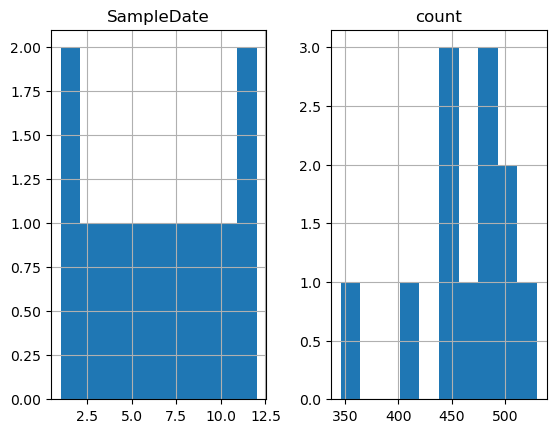

In [29]:
#Look at sample counts over time.
print(hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

    SampleDate  count
6            1    795
7            2    791
9            3    766
10           4    718
2            5    827
4            6    805
8            7    786
1            8    886
3            9    809
0           10    981
11          11    658
5           12    803


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

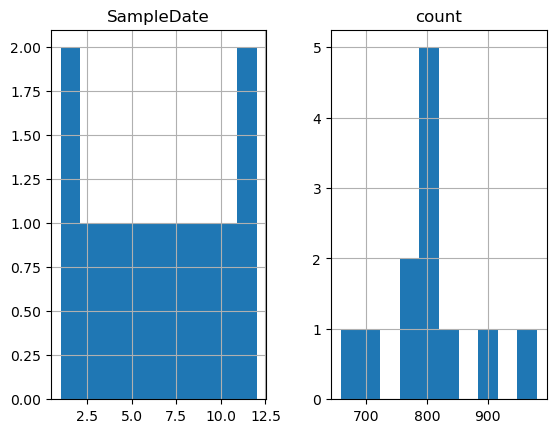

In [30]:
# Checking for distribution of sample counts by month
print(mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

#### Preliminary EDA and processing of subset, 1990

In [31]:
mtbwq1990=mtbwq[mtbwq.SampleDate.dt.year==1990]

In [32]:
mtbwq1990[mtbwq1990.SampleDate.dt.month==1].sort_values(by='SampleDate')

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
510825,20007,Middle Tampa Bay,HCEPC_WQ,32,Tampa Bay Marker 5G,"=""32""",27.7931,-82.570600,1558C,1990-01-03 00:00:00,3.20,m,Cond_umhocm,Specific conductance,NaN,45300.00,umho,NaN,NaN,NaN,NaN
130386,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Turb_ntu,Turbidity,NaN,3.00,NTU,NaN,NaN,NaN,NaN
130385,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Tcoli_100ml,Total Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
130384,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,TKN_ugl,"Nitrogen, Kjeldahl",NaN,680.00,ug/l,NaN,NaN,NaN,NaN
130383,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Fcoli_100ml,Fecal Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82437,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TP_mgl,Phosphorus as P,NaN,0.52,mg/l,NaN,NaN,0.52,mg/L
82438,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TKN_mgl,"Nitrogen, Kjeldahl",NaN,1.31,mg/l,NaN,NaN,1.31,mg/L
82439,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TN_mgl,Nitrogen,NaN,1.38,mg/l,C,NaN,1.38,mg/L
82427,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,norg_ugl,"Nitrogen, organic",NaN,1270.00,ug/l,C,NaN,1.27,mg/L


In [33]:
hbwq1990=hbwq[hbwq.SampleDate.dt.year==1990]

In [34]:
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)

In [35]:
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

In [36]:
hbwq1990_samplefreq=hbwq1990.SampleDate.value_counts().reset_index().sort_values(by='SampleDate').reset_index(drop=True)

<Axes: >

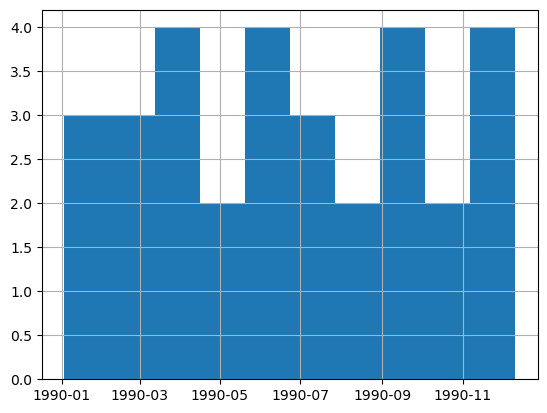

In [37]:
hbwq1990_samplefreq.SampleDate.hist()

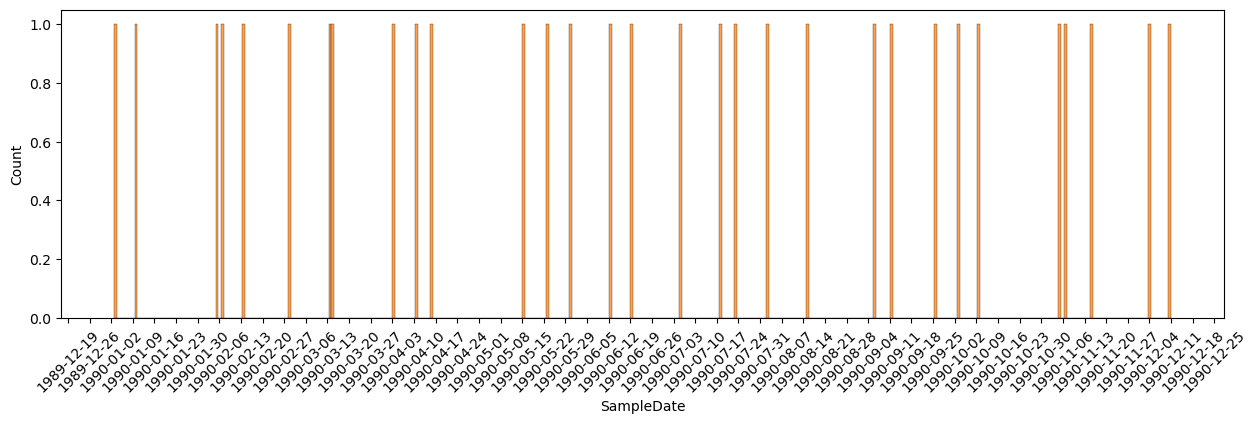

In [38]:
import matplotlib.dates as mdates

plt.figure(figsize=(15,4))
sns.histplot()
ax = sns.histplot(x=hbwq1990_samplefreq.SampleDate,bins=365)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
#plt.xticks(range('1990-01-01','1990-12-31', 365))
plt.show()

In [39]:
hbwq1990

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22449,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22450,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22453,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-03-14,0:00:00,2.59,m,Fecal Coliform,8.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22455,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22457,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-05-16,0:00:00,2.59,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938257,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-05-31,0:00:00,NaN,NaN,Phosphorus as P,0.55,mg/l,NaN,NaN,20005,Hillsborough Bay
938295,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-08-15,0:00:00,NaN,NaN,"Nitrogen, Kjeldahl",0.77,mg/l,NaN,NaN,20005,Hillsborough Bay
938296,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-08-15,0:00:00,NaN,NaN,"Nitrogen, Kjeldahl",0.75,mg/l,NaN,NaN,20005,Hillsborough Bay
938346,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-02-07,0:00:00,NaN,NaN,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",0.04,mg/l,NaN,NaN,20005,Hillsborough Bay


In [40]:
# Isolate Nitrates
nitrogen_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Nitr','nitr')==True]
nitrogen_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22768,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Nitrogen,930.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22769,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Nitrogen,1120.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22770,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-03-14,0:00:00,2.59,m,Nitrogen,720.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22771,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,Nitrogen,610.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22772,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-05-16,0:00:00,2.59,m,Nitrogen,940.0,ug/l,NaN,NaN,20005,Hillsborough Bay


#### Isolation of Compounds

The dataset has multiple entries for each sample event. The same sample is analyzed and described in multiple ways. Consequently, data needs to be isolated to get a consistent single data set.

In [41]:
phosphate_hb=hbwq[hbwq.Characteristic.str.contains('Phos','phos')==True]
phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)
phosphate_hb.head(2)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\4096948815.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
21,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,Phosphorus as P,280.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.2,mg/l,NaN,NaN,20005,Hillsborough Bay


In [42]:
#Isolate Phosphate
phosphate_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Phos','phos')==True]
phosphate_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
23711,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-12-11,0:00:00,0.91,m,"Phosphorus, phosphate (PO4) as P",0.30,mg/l,NaN,NaN,20005,Hillsborough Bay
25728,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-06-13,0:00:00,1.07,m,Phosphorus as P,0.65,mg/l,NaN,NaN,20005,Hillsborough Bay
25729,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-10-10,0:00:00,0.91,m,Phosphorus as P,0.42,mg/l,NaN,NaN,20005,Hillsborough Bay
25764,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-09-12,0:00:00,2.44,m,Phosphorus as P,0.63,mg/l,NaN,NaN,20005,Hillsborough Bay
25849,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-02-14,0:00:00,1.52,m,Phosphorus as P,0.52,mg/l,NaN,NaN,20005,Hillsborough Bay


In [43]:
pd.concat([nitrogen_1990.Characteristic.value_counts(),nitrogen_1990.ResultUnit.value_counts()],axis=1)

,count,count
"Nitrogen, Kjeldahl",362.0,NaN
Nitrogen,349.0,NaN
"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",338.0,NaN
"Nitrogen, ammonia as N",319.0,NaN
"Nitrogen, organic",311.0,NaN
"Nitrogen, Nitrate (NO3) as N",14.0,NaN
mg/l,NaN,831.0
ug/l,NaN,699.0


In [44]:
nitrate1990=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('Nitrogen, Nitrite')]
print(nitrate1990.shape)
nitrate1990.reset_index(drop=True,inplace=True)
nitrate1990.head(3)

(338, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-01-10,0:00:00,1.68,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",10.0,ug/l,NaN,NaN,20005,Hillsborough Bay
1,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-02-14,0:00:00,1.68,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",20.0,ug/l,NaN,NaN,20005,Hillsborough Bay
2,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-03-14,0:00:00,1.83,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",10.0,ug/l,NaN,NaN,20005,Hillsborough Bay


In [45]:
nitrate1990[nitrate1990.ResultUnit.isna()]
nitrate1990.ResultUnit.fillna('ug/l',inplace=True)
nitrate1990[nitrate1990.ResultUnit.isna()]

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\770633725.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nitrate1990.ResultUnit.fillna('ug/l',inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\770633725.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrate1990.ResultUnit.fillna('ug/l',inplace=True)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName


In [46]:
for i in nitrate1990.index:
    if nitrate1990.loc[i,'ResultUnit']=='ug/l':
        nitrate1990.loc[i,'ResultValue']=nitrate1990.loc[i,'ResultValue']/1000
        nitrate1990.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [47]:
nitrate_subset=nitrate1990[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude']]

In [48]:
nitrate_subset['month']=nitrate_subset.SampleDate.dt.month
nitrate_subset

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\2808776215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrate_subset['month']=nitrate_subset.SampleDate.dt.month


,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
0,EPC Water Quality Data,7,1990-01-10,0:00:00,0.010,mg/l,27.858887,-82.468609,1
1,EPC Water Quality Data,7,1990-02-14,0:00:00,0.020,mg/l,27.858887,-82.468609,2
2,EPC Water Quality Data,7,1990-03-14,0:00:00,0.010,mg/l,27.858887,-82.468609,3
3,EPC Water Quality Data,7,1990-04-11,0:00:00,0.020,mg/l,27.858887,-82.468609,4
4,EPC Water Quality Data,7,1990-05-16,0:00:00,0.010,mg/l,27.858887,-82.468609,5
...,...,...,...,...,...,...,...,...,...
333,EPC Monthly Routine Water Monitoring,44,1990-07-18,9:50:00,0.003,mg/l,27.923700,-82.480698,7
334,EPC Monthly Routine Water Monitoring,2,1990-10-10,9:30:00,0.020,mg/l,27.940800,-82.457901,10
335,EPC Monthly Routine Water Monitoring,52,1990-11-07,14:51:00,0.020,mg/l,27.896999,-82.438202,11
336,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,0.040,mg/l,27.859747,-82.451205,2


In [49]:
nitrate_subset_plot=nitrate_subset.groupby('month').ResultValue.agg(['mean','std','min','max'])
nitrate_subset_plot.head(12)

,mean,std,min,max
month,,,,
1,0.022138,0.031466,0.003,0.15
2,0.020667,0.013374,0.010,0.08
3,0.011304,0.003444,0.010,0.02
4,0.013107,0.009171,0.003,0.03
5,0.007826,0.005140,0.003,0.02
6,0.009552,0.005779,0.003,0.02
7,0.009769,0.005969,0.003,0.02
8,0.009455,0.009145,0.003,0.05
9,0.009552,0.006905,0.003,0.03


In [50]:
ammonia1990=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('ammon')].sort_values(by='SampleDate').reset_index(drop=True)
print(ammonia1990.shape)
ammonia1990.head()

(319, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,1990-01-10,13:45:00,0.30,m,"Nitrogen, ammonia as N",0.02,mg/l,JI,NaN,20005,Hillsborough Bay
1,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-01-10,0:00:00,1.52,m,"Nitrogen, ammonia as N",40.00,NaN,NaN,NaN,20005,Hillsborough Bay
2,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,44,NaN,27.923700,-82.480698,1990-01-10,10:45:00,0.70,m,"Nitrogen, ammonia as N",30.00,ug/l,JI,NaN,20005,Hillsborough Bay
3,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,58,NaN,27.939800,-82.419601,1990-01-10,9:47:00,1.50,m,"Nitrogen, ammonia as N",0.06,mg/l,JI,NaN,20005,Hillsborough Bay
4,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,71,NaN,27.876499,-82.413803,1990-01-10,14:27:00,1.10,m,"Nitrogen, ammonia as N",40.00,ug/l,JI,NaN,20005,Hillsborough Bay


In [51]:
# Check for units for standardization
ammonia1990.ResultUnit.value_counts()

ResultUnit
mg/l    168
ug/l    100
Name: count, dtype: int64

In [52]:
ammonia1990[ammonia1990.ResultUnit=='ug/l'].ResultValue

2       30.0
4       40.0
8       60.0
9       20.0
10     100.0
       ...  
306     20.0
313     50.0
314     40.0
315     20.0
316     90.0
Name: ResultValue, Length: 100, dtype: float64

In [53]:
for i in ammonia1990.index:
    if ammonia1990.loc[i,'ResultUnit']=='ug/l':
        ammonia1990.loc[i,'ResultValue']=ammonia1990.loc[i,'ResultValue']/1000
        ammonia1990.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [54]:
ammonia1990.ResultUnit.value_counts()

ResultUnit
mg/l    268
Name: count, dtype: int64

In [55]:
ammonia_subset=ammonia1990[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude']]

In [56]:
print(ammonia_subset.duplicated().value_counts())
ammonia_subset=ammonia_subset.drop_duplicates()
print(ammonia_subset.duplicated().value_counts())
ammonia_subset.head(5)

False    254
True      65
Name: count, dtype: int64
False    254
Name: count, dtype: int64


,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude
0,EPC Monthly Routine Water Monitoring,2,1990-01-10,13:45:00,0.02,mg/l,27.940800,-82.457901
1,EPC Water Quality Data,6,1990-01-10,0:00:00,40.00,NaN,27.889443,-82.477497
2,EPC Monthly Routine Water Monitoring,44,1990-01-10,10:45:00,0.03,mg/l,27.923700,-82.480698
3,EPC Monthly Routine Water Monitoring,58,1990-01-10,9:47:00,0.06,mg/l,27.939800,-82.419601
4,EPC Monthly Routine Water Monitoring,71,1990-01-10,14:27:00,0.04,mg/l,27.876499,-82.413803


In [57]:
ammonia_subset.ResultUnit.fillna('ug/l',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\2065165386.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ammonia_subset.ResultUnit.fillna('ug/l',inplace=True)


In [58]:
for i in ammonia_subset.index:
    if ammonia_subset.loc[i,'ResultUnit']=='ug/l':
        ammonia_subset.loc[i,'ResultValue']=ammonia1990.loc[i,'ResultValue']/1000
        ammonia_subset.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [59]:
ammonia_subset['month']=ammonia_subset.SampleDate.dt.month

In [60]:
ammonia_subset_plot=ammonia_subset.groupby('month').ResultValue.agg(['mean','std','min','max'])
ammonia_subset_plot.head(12)

,mean,std,min,max
month,,,,
1,0.056111,0.024044,0.02,0.10
2,0.048571,0.029204,0.02,0.11
3,0.046842,0.013355,0.02,0.07
4,0.049545,0.032142,0.01,0.11
5,0.049200,0.023965,0.01,0.10
6,0.082105,0.066297,0.01,0.19
7,0.044783,0.042412,0.01,0.17
8,0.092917,0.053931,0.02,0.20
9,0.076522,0.069649,0.01,0.19


In [238]:
pwd

'J:\\Brainstation\\BS Git\\data\\human Imact'

In [240]:
combwq.to_csv('NIT_FINAL.csv')

<Axes: xlabel='month', ylabel='mean'>

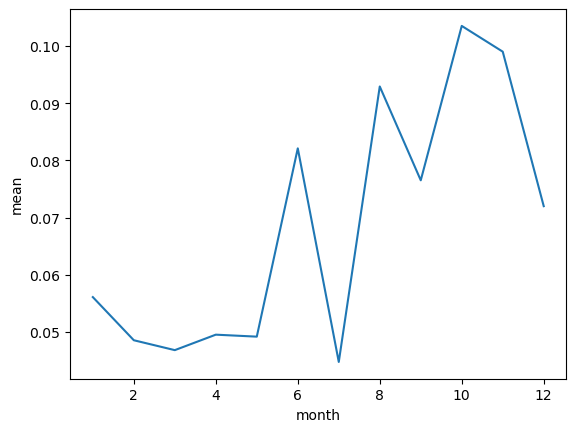

In [61]:
sns.lineplot(x='month',y='mean',data=ammonia_subset_plot,errorbar=('ci',95))

In [62]:
kjedahl=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('Kjeld')]
print(kjedahl.shape)
kjedahl.head(5)

(362, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
25672,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,"Nitrogen, Kjeldahl",0.60,mg/l,NaN,NaN,20005,Hillsborough Bay
25735,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-02-14,0:00:00,1.68,m,"Nitrogen, Kjeldahl",1.13,mg/l,NaN,NaN,20005,Hillsborough Bay
25736,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-08-15,0:00:00,2.13,m,"Nitrogen, Kjeldahl",0.76,mg/l,NaN,NaN,20005,Hillsborough Bay
25739,EPC Water Quality Data,HCEPC_WQ,70,NaN,27.908888,-82.463055,1990-07-18,0:00:00,1.52,m,"Nitrogen, Kjeldahl",0.38,mg/l,NaN,NaN,20005,Hillsborough Bay
25884,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-07-18,0:00:00,1.98,m,"Nitrogen, Kjeldahl",0.61,mg/l,NaN,NaN,20005,Hillsborough Bay


In [63]:
print(kjedahl.ResultUnit.isna().value_counts())
kjedahl.ResultUnit.value_counts()

ResultUnit
False    340
True      22
Name: count, dtype: int64


ResultUnit
mg/l    170
ug/l    170
Name: count, dtype: int64

In [64]:
kjedahl[kjedahl.ResultUnit=='ug/l'].head()

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
26914,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-12-11,10:00:00,1.6,m,"Nitrogen, Kjeldahl",460.00001,ug/l,NaN,NaN,20005,Hillsborough Bay
27002,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-10-10,10:30:00,1.7,m,"Nitrogen, Kjeldahl",479.99999,ug/l,NaN,NaN,20005,Hillsborough Bay
27034,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-09-12,10:33:00,1.8,m,"Nitrogen, Kjeldahl",649.99998,ug/l,NaN,NaN,20005,Hillsborough Bay
27062,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-08-15,10:29:00,2.0,m,"Nitrogen, Kjeldahl",810.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
27093,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-07-18,10:18:00,2.0,m,"Nitrogen, Kjeldahl",610.00001,ug/l,NaN,NaN,20005,Hillsborough Bay


In [65]:
for i in kjedahl.index:
    if kjedahl.loc[i,'ResultUnit']=='ug/l':
        kjedahl.loc[i,'ResultValue']=kjedahl.loc[i,'ResultValue']/1000
        kjedahl.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [66]:
kjedahl.sort_values(by='SampleDate').reset_index(drop=True,inplace=True)

In [67]:
kjedahl.reset_index(drop=True,inplace=True)
kjedahl.sort_values(by='SampleDate').reset_index(drop=True,inplace=True)

In [68]:
kjedahl['month']=kjedahl.SampleDate.dt.month

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\2929928069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjedahl['month']=kjedahl.SampleDate.dt.month


In [69]:
kjedahl_subset=kjedahl[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]

In [70]:
kjedahl_subset.head(5)

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
0,EPC Water Quality Data,55,1990-04-11,0:00:00,0.60,mg/l,27.849166,-82.431385,4
1,EPC Water Quality Data,7,1990-02-14,0:00:00,1.13,mg/l,27.858887,-82.468609,2
2,EPC Water Quality Data,7,1990-08-15,0:00:00,0.76,mg/l,27.858887,-82.468609,8
3,EPC Water Quality Data,70,1990-07-18,0:00:00,0.38,mg/l,27.908888,-82.463055,7
4,EPC Water Quality Data,6,1990-07-18,0:00:00,0.61,mg/l,27.889443,-82.477497,7


In [71]:
kjedahl_subset[kjedahl_subset.ResultValue>2]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
235,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,520.0,NaN,27.859747,-82.451205,5
236,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,530.0,NaN,27.859747,-82.451205,5
237,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,560.0,NaN,27.859747,-82.451205,5
238,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,570.0,NaN,27.859747,-82.451205,5
239,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,580.0,NaN,27.859747,-82.451205,5
240,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,890.0,NaN,27.859747,-82.451205,5
241,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,910.0,NaN,27.859747,-82.451205,5
245,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,540.0,NaN,27.859747,-82.451205,2
246,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,580.0,NaN,27.859747,-82.451205,2
247,USGS National Water Information System,2.75134E+14,1990-04-16,0:00:00,700.0,NaN,27.859747,-82.451205,4


In [72]:
for i in kjedahl.index:
    if kjedahl_subset.loc[i,'ResultValue']>2:
            kjedahl_subset.loc[i,'ResultValue']=kjedahl_subset.loc[i,'ResultValue']/1000
            kjedahl_subset.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [73]:
kjedahl_subset_plot=kjedahl_subset.groupby('month').ResultValue.agg(['mean','std','max','min'])
kjedahl_subset_plot.head(12)

,mean,std,max,min
month,,,,
1,0.801200,0.158465,1.04,0.35
2,1.025000,0.164102,1.22,0.54
3,0.802500,0.162791,1.17,0.62
4,0.721724,0.126324,0.90,0.51
5,0.840976,0.224853,1.23,0.43
6,0.378462,0.072757,0.46,0.25
7,0.514074,0.131274,0.73,0.34
8,0.688286,0.078870,0.81,0.56
9,0.592121,0.084549,0.71,0.42


In [74]:
nitrate_subset_plot

,mean,std,min,max
month,,,,
1,0.022138,0.031466,0.003,0.15
2,0.020667,0.013374,0.010,0.08
3,0.011304,0.003444,0.010,0.02
4,0.013107,0.009171,0.003,0.03
5,0.007826,0.005140,0.003,0.02
6,0.009552,0.005779,0.003,0.02
7,0.009769,0.005969,0.003,0.02
8,0.009455,0.009145,0.003,0.05
9,0.009552,0.006905,0.003,0.03


<Axes: xlabel='month', ylabel='mean'>

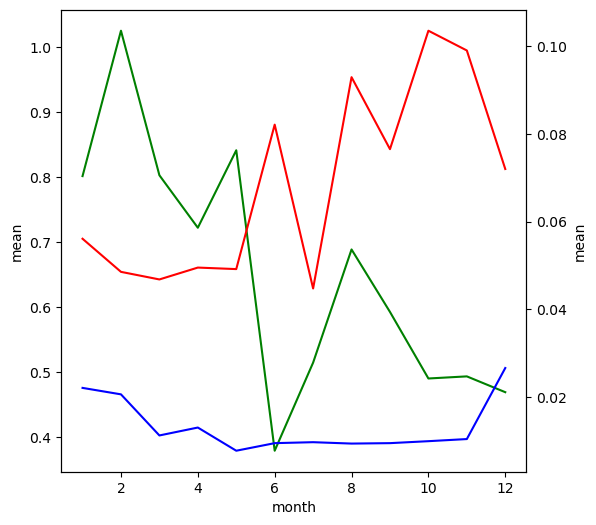

In [75]:
fig,ax=plt.subplots(figsize=(6,6))
sns.lineplot(x='month',y='mean',data=kjedahl_subset_plot,errorbar=('ci',.95),color='green',ax=ax)
ax1=ax.twinx()
sns.lineplot(x='month',y='mean',data=ammonia_subset_plot,errorbar=('ci',.95),color='red',ax=ax1)
sns.lineplot(x='month',y='mean',data=nitrate_subset_plot,errorbar=('ci',.95),color='blue',ax=ax1)

In [76]:
hbconcat=hbwq[['DataSourceName','StationID','Latitude','Longitude','SampleDate','SampleTime','Characteristic','ResultUnit','ResultValue','WaterbodyName']]
hbconcat.head(3)

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fluorides,mg/l,1.0,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fecal Coliform,cfu/100ml,10.0,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved Solids,mg/l,27200.0,Hillsborough Bay


In [77]:
mtbwq['SampleTime']='0:00:00'

In [78]:
mtbwq.head(1)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit,SampleTime
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l,0:00:00


In [79]:
mtbconcat=mtbwq[['DataSource','StationID','Latitude','Longitude','SampleDate','SampleTime','Characteristic','Result_Unit','Result_Value','WaterBodyName']]
mtbconcat.head(3)

,DataSource,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,Result_Unit,Result_Value,WaterBodyName
0,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,Chloride,NaN,18000.0,Middle Tampa Bay
1,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,550.0,Middle Tampa Bay
2,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,580.0,Middle Tampa Bay


In [80]:
mtbconcat.DataSource.isna().value_counts()

DataSource
False    544257
Name: count, dtype: int64

In [81]:
hbconcat

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fluorides,mg/l,1.00,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fecal Coliform,cfu/100ml,10.00,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved Solids,mg/l,27200.00,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved oxygen saturation,percent (%),80.80,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved oxygen (DO),mg/l,4.68,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
1048570,National Ocean Service (NOS) Center for Operat...,8726667,27.916667,-82.433333,2014-04-09,20:54:00,NaN,NaN,0.88,Hillsborough Bay
1048571,National Ocean Service (NOS) Center for Operat...,8726667,27.916667,-82.433333,2014-04-09,20:48:00,NaN,NaN,0.86,Hillsborough Bay
1048572,National Ocean Service (NOS) Center for Operat...,8726667,27.916667,-82.433333,2014-04-09,20:42:00,NaN,NaN,0.85,Hillsborough Bay
1048573,National Ocean Service (NOS) Center for Operat...,8726667,27.916667,-82.433333,2014-04-09,20:36:00,NaN,NaN,0.83,Hillsborough Bay


In [82]:
mtbconcat.rename(columns={'WaterBodyName':'WaterbodyName','DataSource':'DataSourceName','Result_Unit':'ResultUnit','Result_Value':'ResultValue'},inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\3578658420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mtbconcat.rename(columns={'WaterBodyName':'WaterbodyName','DataSource':'DataSourceName','Result_Unit':'ResultUnit','Result_Value':'ResultValue'},inplace=True)


In [83]:
mtbconcat

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,Chloride,NaN,18000.000,Middle Tampa Bay
1,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,550.000,Middle Tampa Bay
2,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,580.000,Middle Tampa Bay
3,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, Nitrate (NO3) as N",NaN,10.000,Middle Tampa Bay
4,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,pH,NaN,8.300,Middle Tampa Bay
...,...,...,...,...,...,...,...,...,...,...
544252,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,Phosphorus as P,mg/l,0.140,Middle Tampa Bay
544253,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,"Nitrogen, ammonia as N",mg/l,0.280,Middle Tampa Bay
544254,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,"Nitrogen, Kjeldahl",mg/l,0.920,Middle Tampa Bay
544255,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,Nitrogen,ug/l,945.000,Middle Tampa Bay


In [2184]:
combwq

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
18,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,5.00,Hillsborough Bay
81,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-10 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,4.00,Hillsborough Bay
89,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-03-06 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,32.00,Hillsborough Bay
116,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-02-14 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,14.00,Hillsborough Bay
159,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-11-07 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,8.00,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
544156,PINELLAS,E6,27.811150,-82.594590,2012-12-05 11:11:00,0:00:00,"Nitrogen, ammonia (NH3) + ammonium (NH4)",ug/l,10.00,Middle Tampa Bay
544174,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, ammonia (NH3) + ammonium (NH4)",ug/l,10.00,Middle Tampa Bay
544188,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, ammonia (NH3) + ammonium (NH4)",mg/l,0.01,Middle Tampa Bay
544234,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19 00:00:00,0:00:00,"Nitrogen, ammonia as N",ug/l,280.00,Middle Tampa Bay


In [2185]:
combwq=pd.concat([hbconcat,mtbconcat])

In [2186]:
combwq[combwq.Characteristic.str.contains('Nit')==True].Characteristic.value_counts()

Characteristic
Nitrogen, Kjeldahl                                       44832
Nitrogen, ammonia as N                                   41417
Nitrogen                                                 35759
Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N             34215
Nitrogen, organic                                        31881
Nitrogen, Nitrate (NO3) as N                              5422
Nitrogen, ammonia (NH3) + ammonium (NH4)                  2157
Nitrogen, Nitrite (NO2) as N                               560
Nitrogen, Ammonium (NH4) as N                               28
Nitrogen, mixed forms (NH3)+(NH4)+organic+(NO2)+(NO3)       14
Nitrogen, ammonium (NH4) as N                                5
Name: count, dtype: int64

In [2187]:
combwq.shape

(1592832, 10)

In [2189]:
### There was one sampling station / service that was producing highly irregular nitrate values
### I suspect that they were correct - but there were so few measurements that, as significant outliers, it was better
### to remove them from the dataset. They were orders higher.

### Samples for this station from all datasets needs to be removed
combwq.drop(combwq[combwq.StationID=='560'].index,inplace=True)

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
16,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03,0:00:00,"Nitrogen, ammonia as N",ug/l,52.000,Hillsborough Bay
17,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03,0:00:00,"Nitrogen, Kjeldahl",ug/l,850.000,Hillsborough Bay
18,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,5.000,Hillsborough Bay
29,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-04,0:00:00,"Nitrogen, ammonia as N",ug/l,22.000,Hillsborough Bay
59,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-03-21,0:00:00,"Nitrogen, Kjeldahl",ug/l,710.000,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
544251,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",mg/l,0.025,Middle Tampa Bay
544253,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,"Nitrogen, ammonia as N",mg/l,0.280,Middle Tampa Bay
544254,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,"Nitrogen, Kjeldahl",mg/l,0.920,Middle Tampa Bay
544255,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19,0:00:00,Nitrogen,ug/l,945.000,Middle Tampa Bay


In [2212]:
combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True]

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
18,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,5.000,Hillsborough Bay
81,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-10 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,4.000,Hillsborough Bay
89,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-03-06 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,32.000,Hillsborough Bay
116,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-02-14 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,14.000,Hillsborough Bay
159,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-11-07 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,8.000,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
544162,PINELLAS,E6,27.811150,-82.594590,2012-12-05 11:11:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544176,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544196,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",mg/l,0.020,Middle Tampa Bay
544236,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,25.000,Middle Tampa Bay


In [2219]:
combwq[combwq.Characteristic.str.contains('Nitrite')==True]

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
18,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,5.000,Hillsborough Bay
81,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-10 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,4.000,Hillsborough Bay
89,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-03-06 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,32.000,Hillsborough Bay
116,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-02-14 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,14.000,Hillsborough Bay
159,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-11-07 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,8.000,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
544162,PINELLAS,E6,27.811150,-82.594590,2012-12-05 11:11:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544176,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544196,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",mg/l,0.020,Middle Tampa Bay
544236,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,25.000,Middle Tampa Bay


In [2234]:
combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True].shape

(39588, 10)

In [2220]:
nitrates=combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True]
kjeldahl=combwq[combwq.Characteristic.str.lower().str.contains('kjel')==True]
ammonia=combwq[combwq.Characteristic.str.lower().str.contains('ammo')==True]

In [2237]:
print(nitrates.shape)
print(kjeldahl.shape)
print(ammonia.shape)

(39588, 10)
(44774, 10)
(43553, 10)


In [2239]:
nitrates_mg=nitrates[nitrates.ResultUnit=='mg/l']
kjeldahl_mg=kjeldahl[kjeldahl.ResultUnit=='mg/l']
ammonia_mg=ammonia[ammonia.ResultUnit=='mg/l']

In [2240]:
print(nitrates_mg.shape)
print(kjeldahl_mg.shape)
print(ammonia_mg.shape)

(19650, 10)
(22302, 10)
(22151, 10)


In [2241]:
nitrates_mg.dropna(inplace=True)
kjeldahl_mg.dropna(inplace=True)
ammonia_mg.dropna(inplace=True)
print(nitrates_mg.shape)
print(kjeldahl_mg.shape)
print(ammonia_mg.shape)

(19527, 10)
(22291, 10)
(22074, 10)


C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\478824487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrates_mg.dropna(inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\478824487.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahl_mg.dropna(inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\478824487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammonia_mg.dropna(inplace=True)


In [2247]:
nitrates_mg.ResultValue.isna().value_counts()

ResultValue
False    19527
Name: count, dtype: int64

In [2248]:
ammonia_mg.ResultValue.isna().value_counts()

ResultValue
False    22074
Name: count, dtype: int64

In [2249]:
kjeldahl_mg.ResultValue.isna().value_counts()

ResultValue
False    22291
Name: count, dtype: int64

In [2262]:
ammoniasub[ammoniasub.ResultValue>2]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year,day,DateMonth


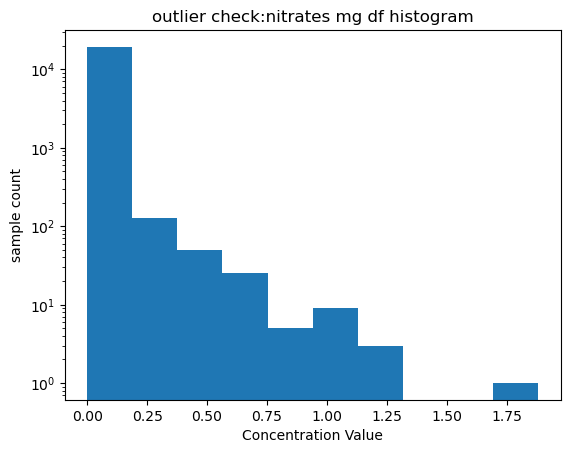

In [2293]:
plt.hist(nitrates_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:nitrates mg df histogram')
plt.show()

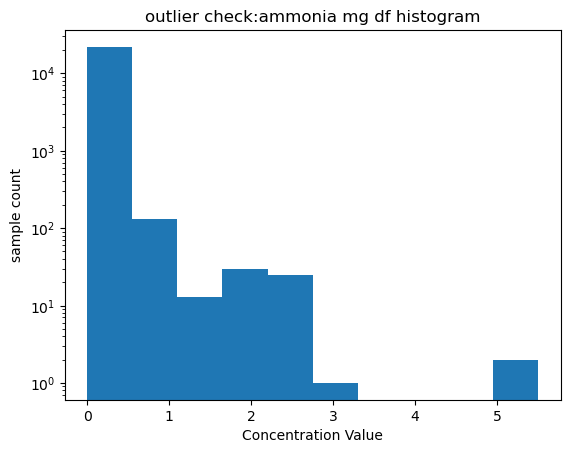

In [2294]:
plt.hist(ammonia_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:ammonia mg df histogram')
plt.show()

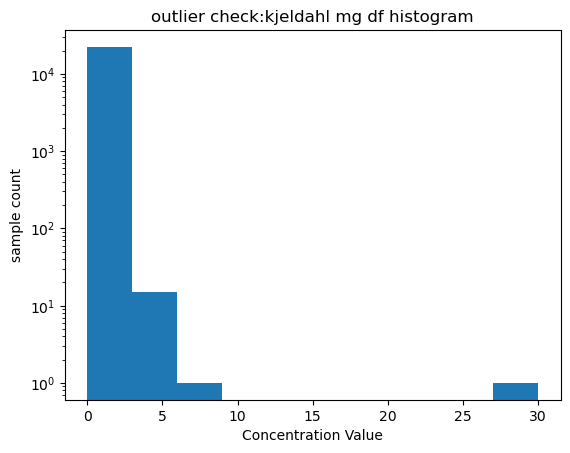

In [2295]:
plt.hist(kjeldahl_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:kjeldahl mg df histogram')
plt.show()

In [2297]:
## This value will get removed when the dataset time period is reduced
kjeldahl_mg[kjeldahl_mg.ResultValue>10]

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName,month
205105,LEGACYSTORET_21FLA,24020904,27.812694,-82.484278,1975-05-28,0:00:00,"Nitrogen, Kjeldahl",mg/l,30.0,Middle Tampa Bay,5


In [2252]:
nitrates_mg_temp=nitrates_mg.reset_index()
#nitrates_mg[nitrates_mg.ResultValue>3].reset_index()
nit_iloc=nitrates_mg_temp[nitrates_mg_temp.ResultValue>2.5].index
for i in nit_iloc:
    nitrates_mg.iloc[i,-2]=nitrates_mg.iloc[i,-2]/1000

In [2298]:
kjeldahl_mg['month']=kjeldahl_mg.SampleDate.dt.month
ammonia_mg['month']=ammonia_mg.SampleDate.dt.month
nitrates_mg['month']=nitrates_mg.SampleDate.dt.month

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\390769954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahl_mg['month']=kjeldahl_mg.SampleDate.dt.month
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\390769954.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammonia_mg['month']=ammonia_mg.SampleDate.dt.month
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\390769954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

In [2299]:
kjeldahlsub=kjeldahl_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]
ammoniasub=ammonia_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]
nitratesub=nitrates_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]

In [2300]:
index_amm_temp=ammoniasub[ammoniasub.ResultValue>3].index
ammoniasub.loc[index_amm_temp].ResultValue=ammoniasub.loc[index_amm_temp].ResultValue/1000

In [2301]:
kjeldahl_mg[kjeldahl_mg.StationID=='560']

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName,month


In [2302]:
kjeldahlsub['year']=kjeldahlsub.SampleDate.dt.year
ammoniasub['year']=ammoniasub.SampleDate.dt.year
nitratesub['year']=nitratesub.SampleDate.dt.year

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\3036575635.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahlsub['year']=kjeldahlsub.SampleDate.dt.year
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\3036575635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammoniasub['year']=ammoniasub.SampleDate.dt.year
C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\3036575635.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [2303]:
kjeldahlsub['day']=1
ammoniasub['day']=1
nitratesub['day']=1

In [2304]:
kjeldahlsub['DateMonth']=pd.to_datetime(kjeldahlsub.astype(str).month+'-'+kjeldahlsub.astype(str).day+'-'+kjeldahlsub.astype(str).year)
ammoniasub['DateMonth']=pd.to_datetime(ammoniasub.astype(str).month+'-'+ammoniasub.astype(str).day+'-'+ammoniasub.astype(str).year)
nitratesub['DateMonth']=pd.to_datetime(nitratesub.astype(str).month+'-'+nitratesub.astype(str).day+'-'+nitratesub.astype(str).year)

In [2305]:
kjeldahlsub=kjeldahlsub[kjeldahlsub.year>1989]
nitratesub=nitratesub[nitratesub.year>1989]
ammoniasub=ammoniasub[ammoniasub.year>1989]

In [2306]:
nitratesub.SampleDate=pd.to_datetime(nitratesub.SampleDate.astype(str).str.slice(0,10))
kjeldahlsub.SampleDate=pd.to_datetime(kjeldahlsub.SampleDate.astype(str).str.slice(0,10))
ammoniasub.SampleDate=pd.to_datetime(ammoniasub.SampleDate.astype(str).str.slice(0,10))

In [2326]:
kjeldahlsub[kjeldahlsub.ResultValue>4]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year,day,DateMonth
168160,Tampa Bay Water,M34,2009-07-27,0:00:00,6.2000,mg/l,27.928000,-82.415000,7,2009,1,2009-07-01
425580,EPC Monthly Routine Water Monitoring,70,1994-10-11,11:05:00,4.1300,mg/l,27.908899,-82.463203,10,1994,1,1994-10-01
439741,EPC Water Quality Data,70,1994-10-11,0:00:00,4.1300,mg/l,27.908888,-82.463055,10,1994,1,1994-10-01
86822,EPC_ROUTINE_MONITORING,136,2003-08-13,0:00:00,4.0600,mg/l,27.680000,-82.499199,8,2003,1,2003-08-01
100452,HCEPC_WQ,136,2003-08-13,0:00:00,4.0600,mg/l,27.680000,-82.499200,8,2003,1,2003-08-01
191363,HCEPC_WQ,19,1998-06-23,0:00:00,4.9357,mg/l,27.693300,-82.555800,6,1998,1,1998-06-01
310031,EPC_ROUTINE_MONITORING,19,1998-06-23,0:00:00,4.9400,mg/l,27.693399,-82.555901,6,1998,1,1998-06-01


**Only Kjeldahl follows a normal distribution, whereas Nitrates and Ammonia are heavily right-skew**
<br>

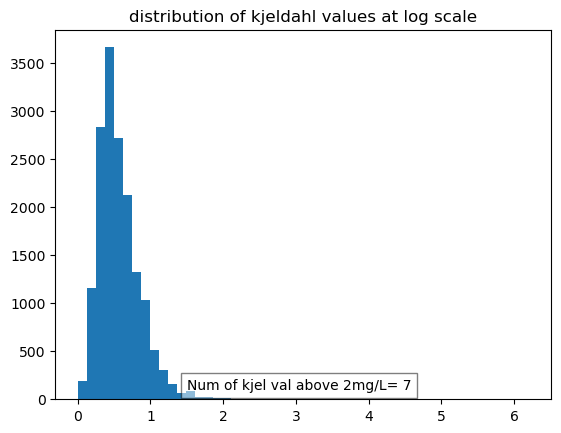

In [2325]:
### Only Kjeldahl has a normal distribution

plt.hist(kjeldahlsub.ResultValue,bins=50)
#"plt.yscale('log')
plt.title('distribution of kjeldahl values at log scale')
plt.text(1.5, 100, f'Num of kjel val above 2mg/L= {kjeldahlsub[kjeldahlsub.ResultValue>4].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

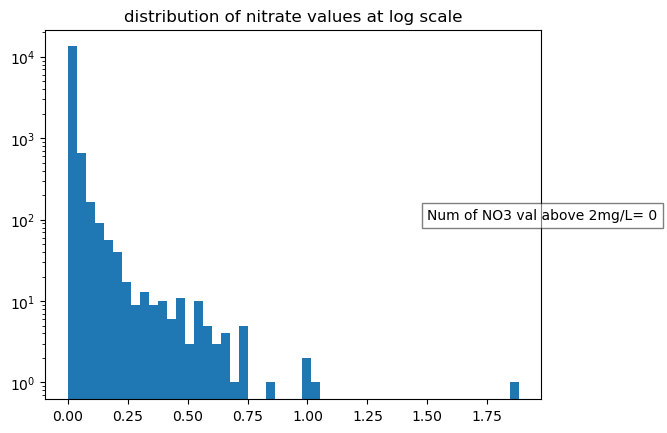

In [2323]:
plt.hist(nitratesub.ResultValue,bins=50)
plt.yscale('log')
plt.title('distribution of nitrate values at log scale')
plt.text(1.5, 100, f'Num of NO3 val above 2mg/L= {nitratesub[nitratesub.ResultValue>2].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

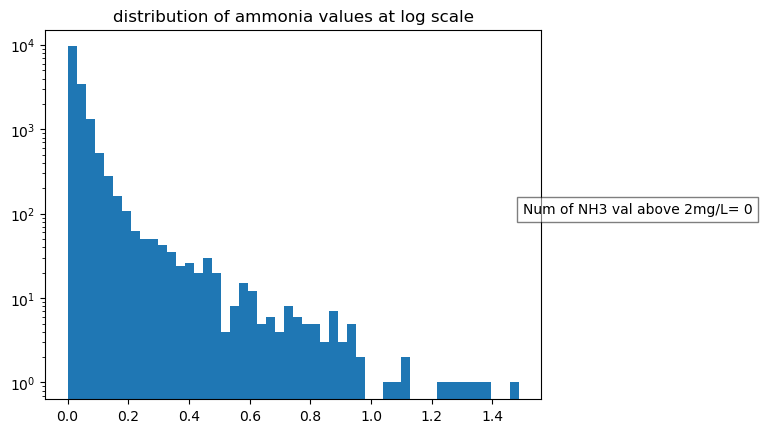

In [2327]:
plt.hist(ammoniasub.ResultValue,bins=50)
plt.yscale('log')
plt.title('distribution of ammonia values at log scale')
plt.text(1.5, 100, f'Num of NH3 val above 2mg/L= {ammoniasub[ammoniasub.ResultValue>2].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [2328]:
# Setting checkpoint
ksub=kjeldahlsub.copy()
asub=ammoniasub.copy()
nsub=nitratesub.copy()

In [2329]:
# Adding some columns to standardize dates and make next steps easier

ksub['week']=ksub.SampleDate.dt.isocalendar().week
asub['week']=asub.SampleDate.dt.isocalendar().week
nsub['week']=nsub.SampleDate.dt.isocalendar().week
ksub['adj_date']=pd.to_datetime(ksub['year'].astype(str) + '-W' + ksub['week'].astype(str) + '-1', format='%Y-W%W-%w')
asub['adj_date']=pd.to_datetime(asub['year'].astype(str) + '-W' + asub['week'].astype(str) + '-1', format='%Y-W%W-%w')
nsub['adj_date']=pd.to_datetime(nsub['year'].astype(str) + '-W' + nsub['week'].astype(str) + '-1', format='%Y-W%W-%w')
ksub.drop(columns='DateMonth',inplace=True)
asub.drop(columns='DateMonth',inplace=True)
nsub.drop(columns='DateMonth',inplace=True)
ksub.sort_values(by='SampleDate',inplace=True)
asub.sort_values(by='SampleDate',inplace=True)
nsub.sort_values(by='SampleDate',inplace=True)

In [2330]:
# There are missing weeks that need to be imputed. This should be weekly data from 1990-2024
# Creating a df with all weeks, including missing values. Will outer join all nitrate groups, remove duplicates, impute or interpolate missing values
data = []
for year in range(1990, 2025):  # 24 years from 1990 to 2024
    for week in range(1, 53):  # Weeks 1 to 52
        data.append([year, week])
weekly=pd.DataFrame(data=data,columns=['year','week'])
weekly['adj_date']=pd.to_datetime(weekly['year'].astype(str) + '-W' + weekly['week'].astype(str) + '-1', format='%Y-W%W-%w')
print(len(data))
print(len(weekly))
print(weekly.min())
weekly.max()

1820
1820
year                       1990
week                          1
adj_date    1990-01-01 00:00:00
dtype: object


year                       2024
week                         52
adj_date    2024-12-23 00:00:00
dtype: object

In [2331]:
# Make sure the datasets are as clean as possible (missing values dealt with later)
ksub.drop_duplicates(inplace=True)
asub.drop_duplicates(inplace=True)
nsub.drop_duplicates(inplace=True)

print(ksub.shape)
print(asub.shape)
print(nsub.shape)

(16150, 13)
(15779, 13)
(14303, 13)


In [2332]:
# outer join kjeldahl df, no loss of data
test=weekly.merge(ksub,left_on=weekly.adj_date,right_on=ksub.adj_date,how='outer',suffixes=('_dt','_K'))

In [2333]:
# adj_date_dt remains complete, dropping key_0
test.info()
test.drop(columns='key_0',inplace=True)
test.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16402 entries, 0 to 16401
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   key_0           16402 non-null  datetime64[ns]
 1   year_dt         16402 non-null  int64         
 2   week_dt         16402 non-null  int64         
 3   adj_date_dt     16402 non-null  datetime64[ns]
 4   DataSourceName  16150 non-null  object        
 5   StationID       16150 non-null  object        
 6   SampleDate      16150 non-null  datetime64[ns]
 7   SampleTime      16150 non-null  object        
 8   ResultValue     16150 non-null  float64       
 9   ResultUnit      16150 non-null  object        
 10  Latitude        16150 non-null  float64       
 11  Longitude       16150 non-null  float64       
 12  month           16150 non-null  float64       
 13  year_K          16150 non-null  float64       
 14  day             16150 non-null  float64       
 15  we

,year_dt,week_dt,adj_date_dt,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year_K,day,week_K,adj_date_K
0,1990,1,1990-01-01,HCEPC_WQ,32,1990-01-03,0:00:00,0.54,mg/l,27.7931,-82.5706,1.0,1990.0,1.0,1,1990-01-01
1,1990,1,1990-01-01,HCEPC_WQ,13,1990-01-03,0:00:00,0.53,mg/l,27.8117,-82.5231,1.0,1990.0,1.0,1,1990-01-01


In [2334]:
# outer join ammonia results, no loss of data
# all units are standardized to mg/l
# need to keep key_0 as it's the only complete date column.
test2=test.merge(asub['ResultValue'],left_on=[test.adj_date_dt,test.DataSourceName,test.StationID],right_on=[asub.adj_date,asub.DataSourceName,asub.StationID],how='outer',suffixes=('_dt','_A')).drop_duplicates()
test2.rename(columns={'key_0':'adj_date'},inplace=True)
test2.drop(columns=['key_1','key_2'],inplace=True)

In [2335]:
# outer join nitrate results, no loss of data
# all units are standardized to mg/l
# last merge

test3=test2.merge(nsub['ResultValue'],left_on=[test2.adj_date,test2.DataSourceName,test2.StationID],right_on=[nsub.adj_date,nsub.DataSourceName,nsub.StationID],how='outer',suffixes=('_dt','_N')).drop_duplicates()

In [2336]:
test3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22461 entries, 0 to 25146
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   key_0           22461 non-null  datetime64[ns]
 1   key_1           20886 non-null  object        
 2   key_2           20886 non-null  object        
 3   adj_date        20439 non-null  datetime64[ns]
 4   year_dt         19116 non-null  float64       
 5   week_dt         19116 non-null  float64       
 6   adj_date_dt     19116 non-null  datetime64[ns]
 7   DataSourceName  18864 non-null  object        
 8   StationID       18864 non-null  object        
 9   SampleDate      18864 non-null  datetime64[ns]
 10  SampleTime      18864 non-null  object        
 11  ResultValue_dt  18864 non-null  float64       
 12  ResultUnit      18864 non-null  object        
 13  Latitude        18864 non-null  float64       
 14  Longitude       18864 non-null  float64       
 15  month  

In [2337]:
# Isolate columns of interest
nmerge_stage=test3[test3.columns[[0,7,13,14,11,20,21]]]

In [2338]:
nmerge_stage.head(1)

,key_0,DataSourceName,Latitude,Longitude,ResultValue_dt,ResultValue_A,ResultValue
0,1990-01-01,EPC_ROUTINE_MONITORING,27.8118,-82.523201,0.53,0.04,0.003


In [2339]:
# Rename columns

nmerge_stage.columns=['date_adj','DataSourcveName','Lat','Long','ResultValue_K','ResultValue_A','ResultValue_N']
print(nmerge_stage.shape)
nmerge_stage.head(2)

(22461, 7)


,date_adj,DataSourcveName,Lat,Long,ResultValue_K,ResultValue_A,ResultValue_N
0,1990-01-01,EPC_ROUTINE_MONITORING,27.8118,-82.523201,0.53,0.04,0.003
1,1990-01-01,EPC_ROUTINE_MONITORING,27.7932,-82.570701,0.54,0.03,0.003


In [2340]:
# Establish independent copy of merged base table
nmerge_base=nmerge_stage.copy()

In [2341]:
nmerge_base[nmerge_base.ResultValue_N>2]

,date_adj,DataSourcveName,Lat,Long,ResultValue_K,ResultValue_A,ResultValue_N


In [2342]:
# Aggregate at weekly date intervals
nmerge_stage2=nmerge_stage.groupby('date_adj').agg({
    'ResultValue_K':'mean',
    'ResultValue_A':'mean',
    'ResultValue_N':'mean'
})

In [2343]:
# Extra weeks beyond the end of the dataset (8/26/24)
# Cut out extra weeks
# Check for nulls
nmerge_stage3=nmerge_stage2.iloc[:-17,:]
nmerge_stage3.isna().sum()

ResultValue_K    235
ResultValue_A    246
ResultValue_N    248
dtype: int64

There are fewer missing values than expected! That's good, interpolation shouldn't be a problem. <br>
Seasonality shouldn't be expected for periods less than a month. <br>
Interpolation with 2 period in both directions should give best approximation of values.<br>

In [2344]:
nmerge=nmerge_stage3.interpolate(method='linear', limit_direction='both', limit=2)

In [2345]:
print(f'{nmerge.info()}\n\n\nSHAPE:\n{nmerge.shape}\n\n\n\nDESCRIBE:\n{nmerge.describe()}')
nmerge.head(2)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1803 entries, 1990-01-01 to 2024-08-26
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ResultValue_K  1803 non-null   float64
 1   ResultValue_A  1803 non-null   float64
 2   ResultValue_N  1803 non-null   float64
dtypes: float64(3)
memory usage: 56.3 KB
None


SHAPE:
(1803, 3)



DESCRIBE:
       ResultValue_K  ResultValue_A  ResultValue_N
count    1803.000000    1803.000000    1803.000000
mean        0.575472       0.055545       0.023528
std         0.298930       0.084185       0.033887
min         0.060000       0.000000       0.000000
25%         0.383333       0.018134       0.007000
50%         0.511389       0.030000       0.013895
75%         0.704722       0.056324       0.024015
max         3.030000       1.028308       0.430000


,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826


In [2346]:
print(f'nmerge shape:\n {nmerge.shape}\n')
print(f'######\n\nMerge1 duplicates: \n{nmerge.duplicated().value_counts}\n\n######\nResultAction:')
if nmerge.duplicated().any():
    print('True.Duplicates, drop\n')
    nmerge.drop_duplicates(inplace=True)
else:
    print('False. No Duplicates, no drop\n')
print(f'######\n\nNulls:\n{nmerge.isna().sum()}\n')
print(f'######\nnew shape:{nmerge.shape}')
if nmerge.columns[0]=='key_0':
    print('Newly created key columns not dropped\nColumns now dropped')
    nmerge.drop(columns=nmerge.columns[[0,1,2]],inplace=True)
else:
    print('Columns not dropped')
nmerge.head(3)


nmerge shape:
 (1803, 3)

######

Merge1 duplicates: 
<bound method IndexOpsMixin.value_counts of date_adj
1990-01-01    False
1990-01-08    False
1990-01-15    False
1990-01-22    False
1990-01-29    False
              ...  
2024-07-29    False
2024-08-05    False
2024-08-12    False
2024-08-19    False
2024-08-26    False
Length: 1803, dtype: bool>

######
ResultAction:
False. No Duplicates, no drop

######

Nulls:
ResultValue_K    0
ResultValue_A    0
ResultValue_N    0
dtype: int64

######
new shape:(1803, 3)
Columns not dropped


,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826
1990-01-15,0.408333,0.071667,0.006500


In [2347]:
os.chdir('J:\\Brainstation\\BS Git\\human Imact\\Nutrient_loading')

In [2348]:
ksub.to_csv('kjeldahl.csv')
nsub.to_csv('nitrate.csv')
asub.to_csv('ammonia.csv')
nmerge.to_csv('nit_merged_mean.csv')

### Nitrates TSA Correlation VAR

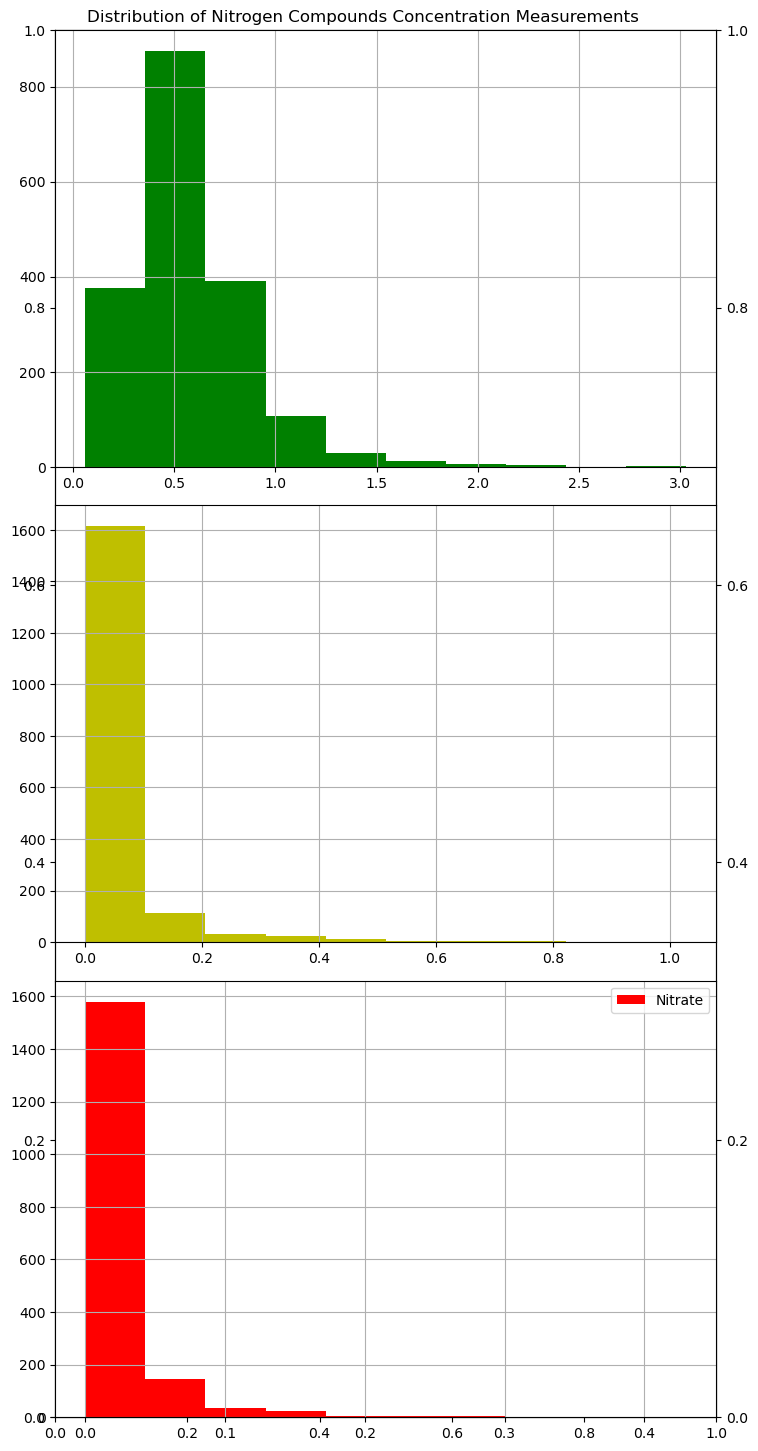

In [2350]:
fig, ax = plt.subplots(figsize=(8,15))
ax1=ax.twinx()
plt.subplot(3,1,1)
nmerge.ResultValue_K.hist(color='g',label='Kjeldahl')
plt.subplot(3,1,2)
nmerge.ResultValue_A.hist(color='y',label='Ammonia')
plt.subplot(3,1,3)
nmerge.ResultValue_N.hist(color='r',label='Nitrate')
#plt.subplot(3,1,4)
plt.legend()
plt.suptitle('Distribution of Nitrogen Compounds Concentration Measurements')
plt.tight_layout()
plt.show()

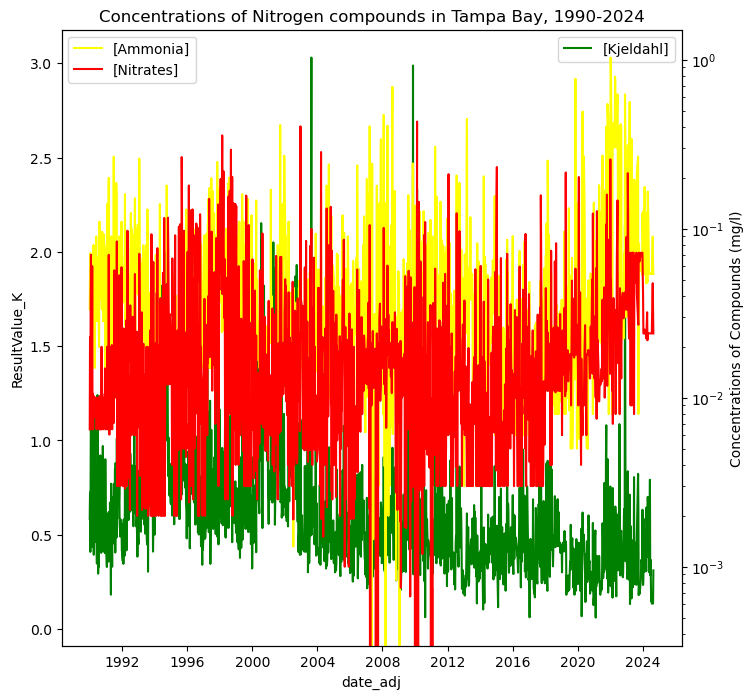

In [2351]:
fig,ax = plt.subplots(figsize=(8,8))

sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_K, label='[Kjeldahl]',color='green',ax=ax)
#plt.xlabel*('Concentrations of Organic Nitrogen (Kjel)')
ax1=ax.twinx()
sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_A, label='[Ammonia]',color='yellow',ax=ax1)
sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_N, label='[Nitrates]',color='red',ax=ax1)
plt.title('Concentrations of Nitrogen compounds in Tampa Bay, 1990-2024')
plt.xlabel('Date')
plt.ylabel('Concentrations of Compounds (mg/l)')
plt.yscale('log')

In [2352]:
nmerge['K_moving_average'] = nmerge.ResultValue_K.rolling(window=36).mean()
nmerge['A_moving_average'] = nmerge.ResultValue_A.rolling(window=36).mean()
nmerge['N_moving_average'] = nmerge.ResultValue_N.rolling(window=36).mean()

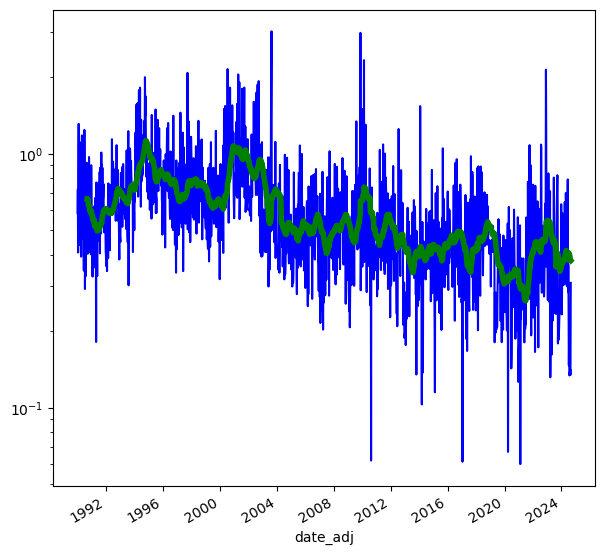

In [2353]:
plt.figure(figsize=(7,7))
nmerge.ResultValue_K.plot(color='b')
nmerge.K_moving_average.plot(color='g',lw=4)
plt.yscale('log')
plt.show()

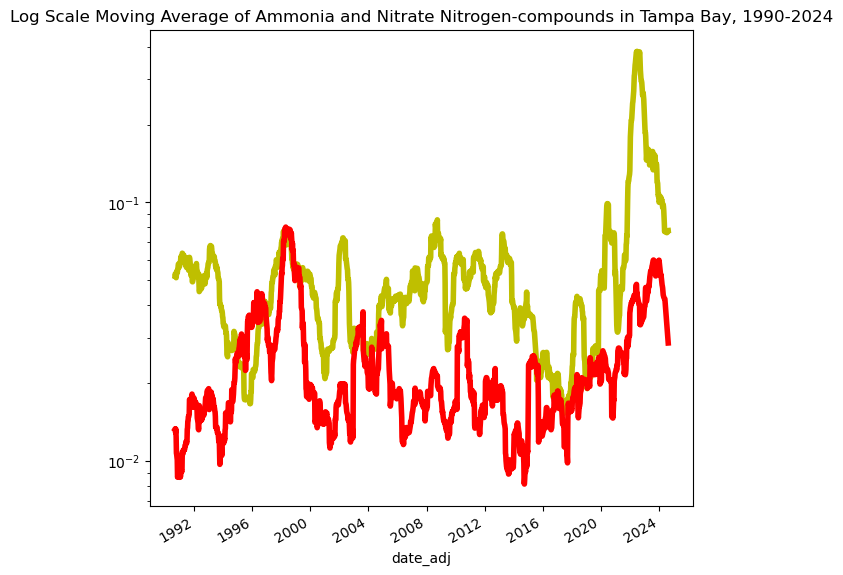

In [2445]:
plt.figure(figsize=(7,7))
nmerge.A_moving_average.plot(color='y',lw=4)
nmerge.N_moving_average.plot(color='r',lw=4)
plt.yscale('log')
plt.title('Log Scale Moving Average of Ammonia and Nitrate Nitrogen-compounds in Tampa Bay, 1990-2024')
plt.show()

Measurements of Nitrogen in Kjeldahl can be understood as measuerments of organic nitrogen found water systems.
Measurements of Ammonia (NH3/NH4+) can be understood as anthropogenic sources of nitrogen
Measurements of Nitrates/Nitrites are anthropogenic sources of nitrogen.

In order to use Ammonia and Nitrates as factors for the API while using Kjeldahl measurements as a feature of the marine ecosystem, it has to be shown that there's correlation between NH3,NO3 ~ Kjel.<br>

This study uses vector autoregression (VAR) to look at these relationships in a time series.

Sampling frequency, measurements have been standardized for frequency and units.<br>
Missing values have been interpolated. 

In [2039]:
### nmerge df Checkpoint

#$nmerge_backup=nmerge.copy()
#nmerge=nmerge_back.copy()

In [2355]:
nmerge.index

DatetimeIndex(['1990-01-01', '1990-01-08', '1990-01-15', '1990-01-22',
               '1990-01-29', '1990-02-05', '1990-02-12', '1990-02-19',
               '1990-02-26', '1990-03-05',
               ...
               '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15',
               '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12',
               '2024-08-19', '2024-08-26'],
              dtype='datetime64[ns]', name='date_adj', length=1803, freq=None)

In [2041]:
nmergeK=pd.Series(nmerge.ResultValue_K)
nmergeK.index=nmerge.index

In [2357]:
nmerge.iloc[:,:-3]

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826
1990-01-15,0.408333,0.071667,0.006500
1990-01-22,0.859167,0.055833,0.038250
1990-01-29,1.310000,0.040000,0.070000
...,...,...,...
2024-07-29,0.136519,0.066000,0.031852
2024-08-05,0.139037,0.078000,0.039704
2024-08-12,0.141556,0.090000,0.047556


In [2358]:
nmerge.iloc[:,-3:].describe()

,K_moving_average,A_moving_average,N_moving_average
count,1768.000000,1768.000000,1768.000000
mean,0.576596,0.055450,0.023557
std,0.185596,0.050157,0.013198
min,0.263658,0.015192,0.008124
25%,0.438922,0.030956,0.015026
50%,0.520672,0.045877,0.018934
75%,0.693186,0.059228,0.027477
max,1.126163,0.384414,0.080274


In [2359]:
VAR_data=nmerge.iloc[:,0:3]
rolling_avg_data=nmerge.iloc[:,:-3]

In [2360]:
scaler1=MinMaxScaler()
scaler2=MinMaxScaler()
scaler1.fit(VAR_data)
VAR_scaled = pd.DataFrame(scaler1.transform(VAR_data), columns=VAR_data.columns, index=VAR_data.index)
scaler2.fit(rolling_avg_data)
rolling_scaled=pd.DataFrame(scaler2.transform(rolling_avg_data), columns=rolling_avg_data.columns, index=rolling_avg_data.index)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\1829982694.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


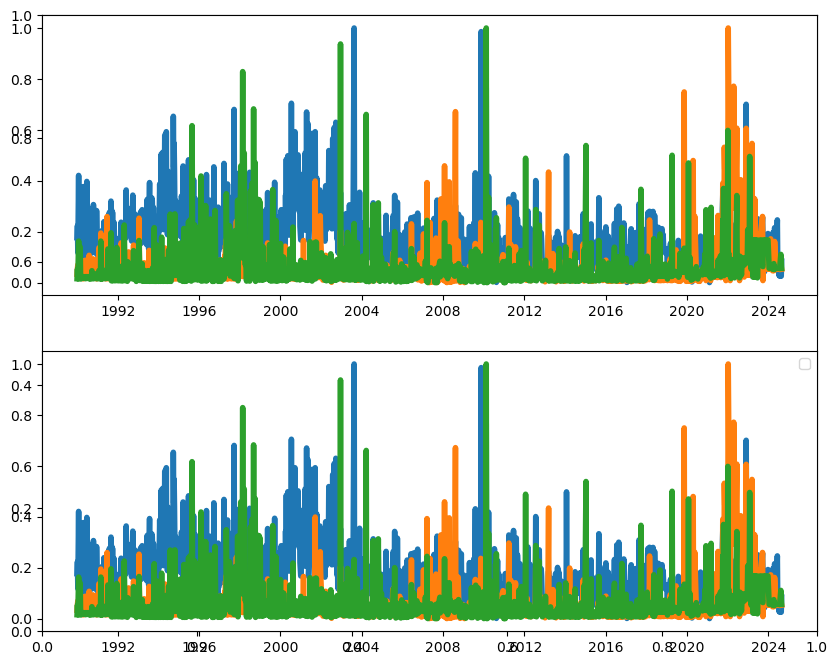

In [2362]:
plt.subplots(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(VAR_scaled,lw=4)
plt.subplot(2,1,2)
plt.plot(rolling_scaled,lw=4)
plt.legend()
plt.show()

In [2486]:
# Data has already been scaled with MinMax

# Splits scaled data
train_data, test_data = train_test_split(VAR_data, test_size=0.3, shuffle=False)

# Scale data
scaler=MinMaxScaler()
scaler.fit(train_data)
train_data_scaled = pd.DataFrame(scaler.transform(train_data), columns=train_data.columns, index=train_data.index)
test_data_scaled = pd.DataFrame(scaler.transform(test_data), columns=test_data.columns, index=test_data.index) 

In [2487]:
VAR_data.head(2)

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826


In [2489]:
train_data_scaled

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.175669,0.048281,0.015116
1990-01-08,0.222956,0.082332,0.053084
1990-01-15,0.116708,0.103805,0.015116
1990-01-22,0.268603,0.080871,0.088953
1990-01-29,0.420498,0.057937,0.162791
...,...,...,...
2014-03-10,0.013835,0.036211,0.006977
2014-03-17,0.085599,0.021051,0.006977
2014-03-24,0.160396,0.295481,0.086047


In [2488]:
test_data_scaled

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
2014-04-14,0.110307,0.098976,0.023256
2014-04-21,0.118999,0.065952,0.007442
2014-04-28,0.131084,0.089803,0.006977
2014-05-05,0.125974,0.063973,0.006977
2014-05-12,0.115248,0.008691,0.006977
...,...,...,...
2024-07-29,0.025129,0.095597,0.074074
2024-08-05,0.025977,0.112978,0.092334
2024-08-12,0.026826,0.130359,0.110594


_**Aug. Dickey-Fuller Test:**_
>Hypothesis-<br>
>**H<sub>0</sub>**: Individual nitrogen-compound features do not exhibit statistically significant stationarity <br>
>**H<sub>1</sub>**: Individual nitrogen-compound features do exhibit stationarity over time

In [2490]:
# Running ADF test
for i in train_data.columns:
    print(f'Unscaled Data:{i}\n{check_stationarity(VAR_data[i])}\n')
    print(f'TRAIN Feature:{i}\n{check_stationarity(train_data_scaled[i])}\n')
    print(f'TEST Feature:{i}\n{check_stationarity(test_data_scaled[i])}\n\n###############')

ADF Statistic: -3.256494122750594
p-value: 0.01693878116500303
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Unscaled Data:ResultValue_K
None

ADF Statistic: -3.506637876884144
p-value: 0.007818246851342995
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
TRAIN Feature:ResultValue_K
None

ADF Statistic: -5.909697751400326
p-value: 2.656785592979214e-07
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
TEST Feature:ResultValue_K
None

###############
ADF Statistic: -4.450748757154138
p-value: 0.00024111096251685151
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Unscaled Data:ResultValue_A
None

ADF Statistic: -7.562957354634023
p-value: 2.976531804038541e-11
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
TRAIN Feature:ResultValue_A
None

ADF Statistic: -2.3800432752219995
p-value: 0.1474484467268114
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
TEST Feature:ResultValue_A
None

###############
ADF Statistic: -7.503429601800928
p-value: 4.19484453633

When run with the original, full unscaled dataset, null hypothesis is rejected
- Scaled Train data demonstrates stationarity for all features.
- Test data instructs to reject the null hypothesis for Ammonia, both a high p-value and small ADF relative to critical values.<br>
ADF statistic < Critical Values(1%)<br><br>

Running VAR next.

**Vector Autoregression**
>Hypothesis-<br>
>**H<sub>0</sub>**: Analysis, through coefficient comparison, predictive comparison and other insights, do not show any definitive differentiation of Kjeldahl values from Nitrates and Ammonia  <br>
>**H<sub>1</sub>**: VAR indicates that Kjeldahl values patterns over time vary significantly from that of _both_ ammonia and nitrates.

In [2491]:
VAR_data

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826
1990-01-15,0.408333,0.071667,0.006500
1990-01-22,0.859167,0.055833,0.038250
1990-01-29,1.310000,0.040000,0.070000
...,...,...,...
2024-07-29,0.136519,0.066000,0.031852
2024-08-05,0.139037,0.078000,0.039704
2024-08-12,0.141556,0.090000,0.047556


In [ ]:
alphas = [0.0001,0.001, 0.01, 0.1,0.2, 0.5, 1]
mse_sklearn = []
mse_sm = []

for a in alphas:

    clf     = linear_model.Lasso(alpha=a)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    mse_sklearn.append(mean_squared_error(y_test, y_pred))

    mdl = sm.OLS(y_train,sm.add_constant(X_train)).fit_regularized(alpha=a,L1_wt=1)
    y_pred = mdl.predict(sm.add_constant(X_test))
    mse_sm.append(mean_squared_error(y_test, y_pred))

In [2520]:
# VAR Model
model = VAR(train_data_scaled)
model2 = VAR(VAR_scaled)
# Fit Scaled VAR Lasso
#results = model.fit(method='ols', alpha=0.1, L1_wt=1, lags=12) 
#results = model.fit(maxlags=12, ic='aic', trend='ct', seas=52)  

C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [2521]:
results4=model.fit(maxlags=4,ic='aic')
results8=model.fit(maxlags=8,ic='aic')
results12=model.fit(maxlags=12,ic='aic')
results16=model.fit(maxlags=16,ic='aic')
results26=model.fit(maxlags=26,ic='aic')
results_whole4=model2.fit(maxlags=4,ic='aic')
results_whole12=model2.fit(maxlags=12,ic='aic')
results_whole26=model2.fit(maxlags=26,ic='aic')

In [2522]:
# Print model 2 (whole data set...just to see) summary

# Results for lag=4
print(results4.summary())
print('4############################################')
# Results for lag=8
print(results8.summary())
print('8############################################')
# Results for lag=12
print(results12.summary())
print('12############################################')

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 08, Dec, 2024
Time:                     14:34:09
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -15.2462
Nobs:                     1258.00    HQIC:                  -15.3456
Log likelihood:           4373.99    FPE:                2.03928e-07
AIC:                     -15.4055    Det(Omega_mle):     1.97734e-07
--------------------------------------------------------------------
Results for equation ResultValue_K
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.066458         0.007944            8.365           0.000
L1.ResultValue_K         0.191265         0.027675            6.911           0.000
L1.ResultValue_A        -0.012605       

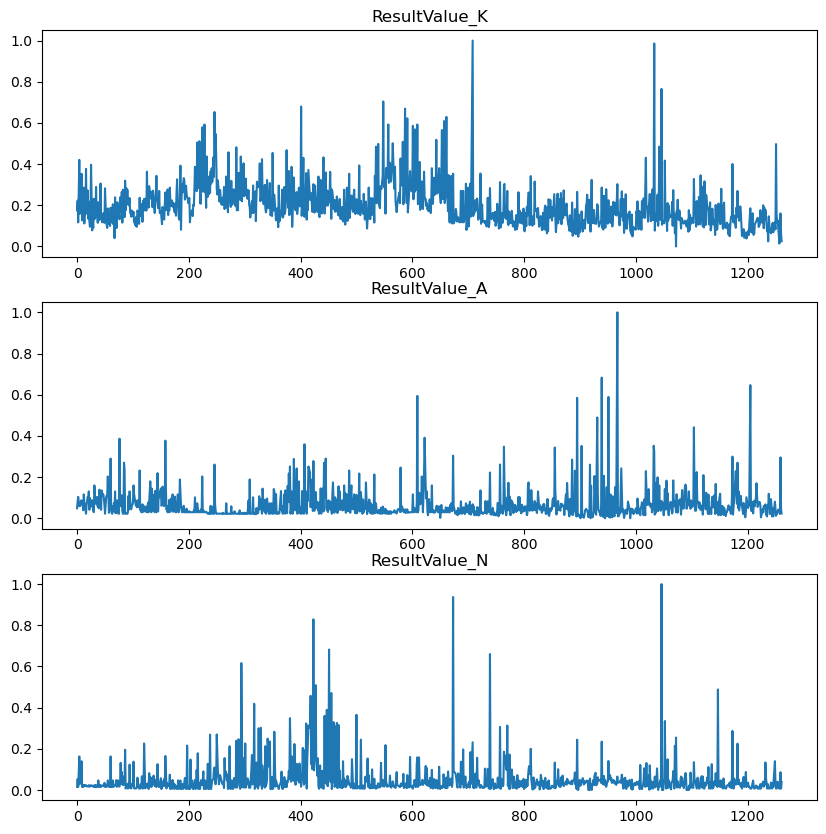

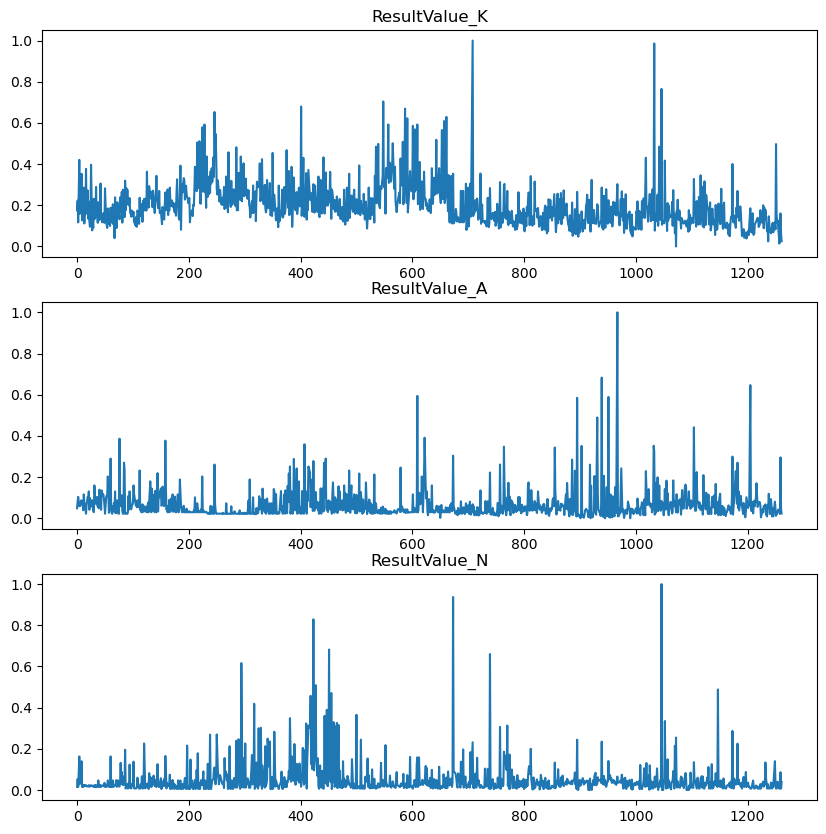

In [2510]:
results4.plot()

In [2515]:
lags = 12  
last_observations = train_data_scaled.values[-lags:]  
forecast = results12.forecast(y=last_observations, steps=len(test_data))

In [2516]:
# Create a DataFrame with actual and forecasted values
forecast_df = pd.DataFrame({
    'Actual_K': test_data['ResultValue_K'],
    'Forecast_K': forecast[:, 0],  # Assuming Kjeldahl is the first variable
    'Actual_A': test_data['ResultValue_A'],
    'Forecast_A': forecast[:, 1],  # Assuming ammonia is the second variable
    'Actual_N': test_data['ResultValue_N'],
    'Forecast_N': forecast[:, 2]   # Assuming nitrates is the third variable
}, index=test_data.index)

# Calculate error metrics (example with MAE)
from sklearn.metrics import mean_absolute_error
mae_k = mean_absolute_error(forecast_df['Actual_K'], forecast_df['Forecast_K'])


In [ ]:
forecast_df

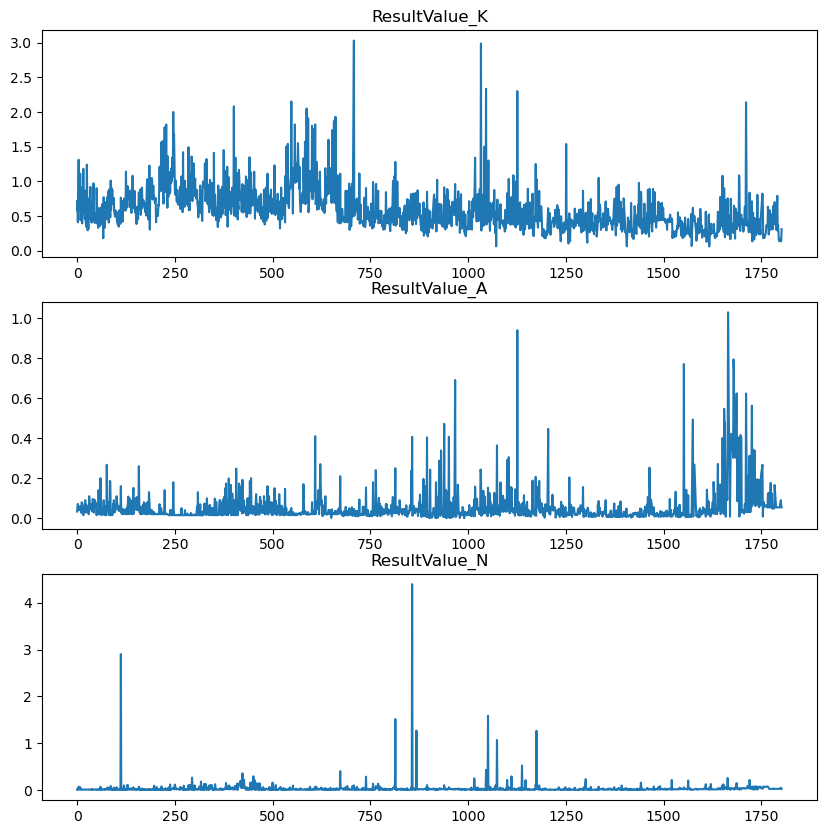

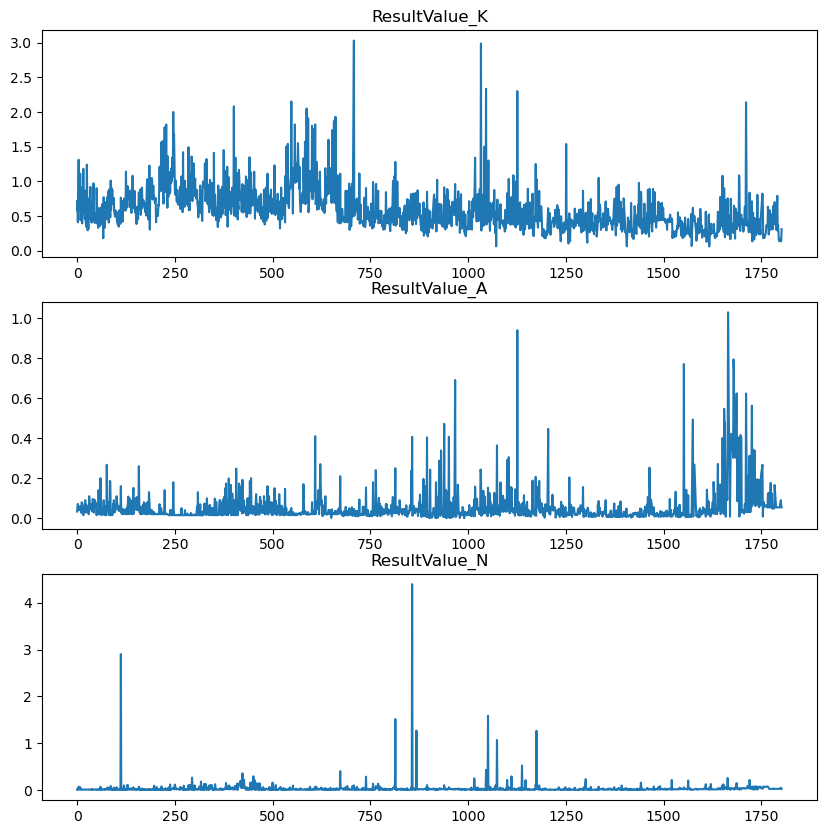

In [1901]:
### Results of the model without forecasting
results.plot()

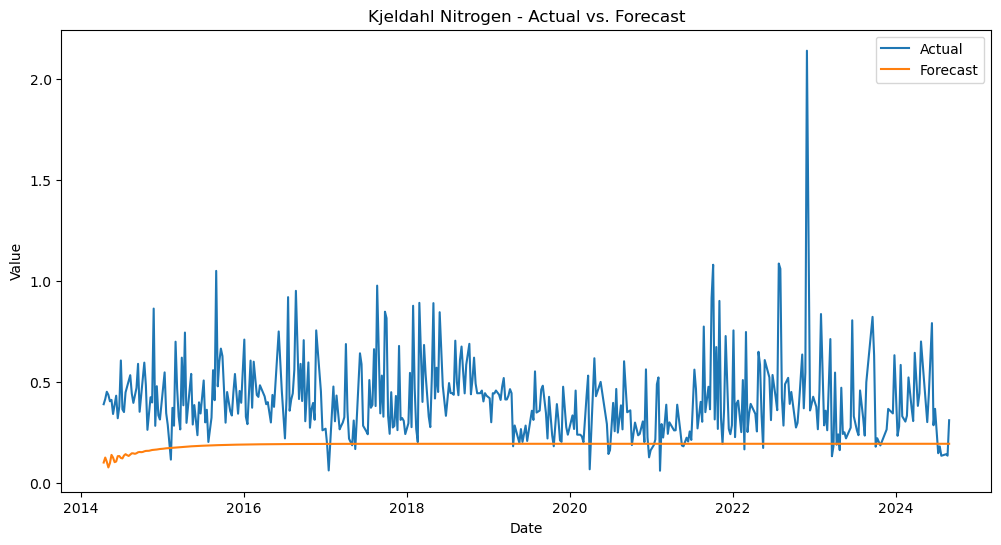

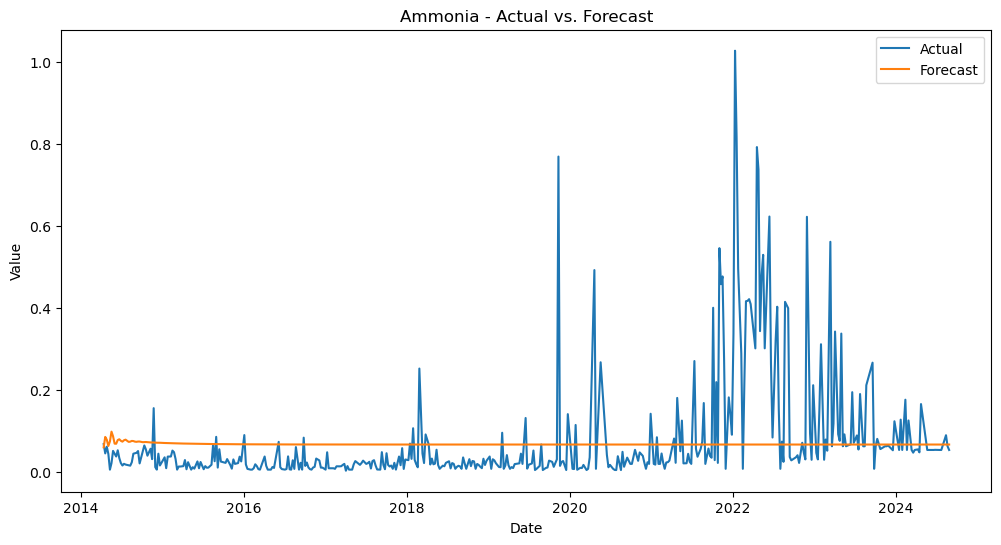

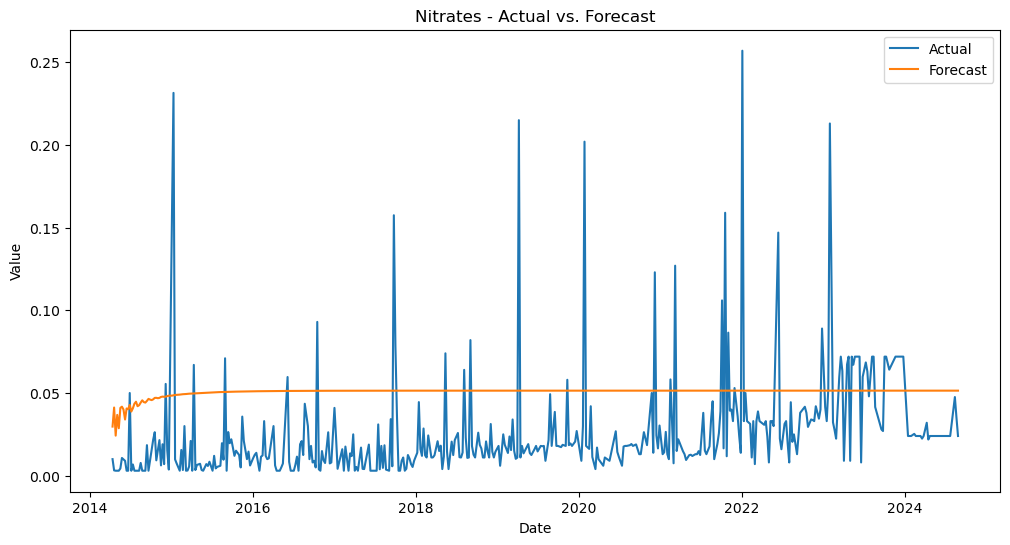

In [2518]:
# Plot the actual vs. forecasted values for Kjeldahl
# The model shows barely any sign of seasonality in the first few forecasted periods before reaching a plateau, where it remains for the rest of the time series.

plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_K'], label='Actual')
plt.plot(forecast_df['Forecast_K'], label='Forecast')
plt.title('Kjeldahl Nitrogen - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Repeat the plotting for ammonia and nitrates
plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_A'], label='Actual')
plt.plot(forecast_df['Forecast_A'], label='Forecast')
plt.title('Ammonia - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_N'], label='Actual')
plt.plot(forecast_df['Forecast_N'], label='Forecast')
plt.title('Nitrates - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

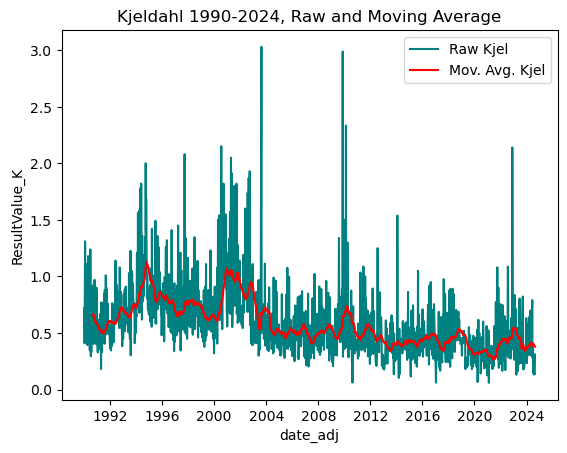

In [2390]:
sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_K,label='Raw Kjel',color='teal')
sns.lineplot(x=nmerge.index,y=nmerge.K_moving_average,label='Mov. Avg. Kjel',color='red')
plt.title('Kjeldahl 1990-2024, Raw and Moving Average')
plt.show()

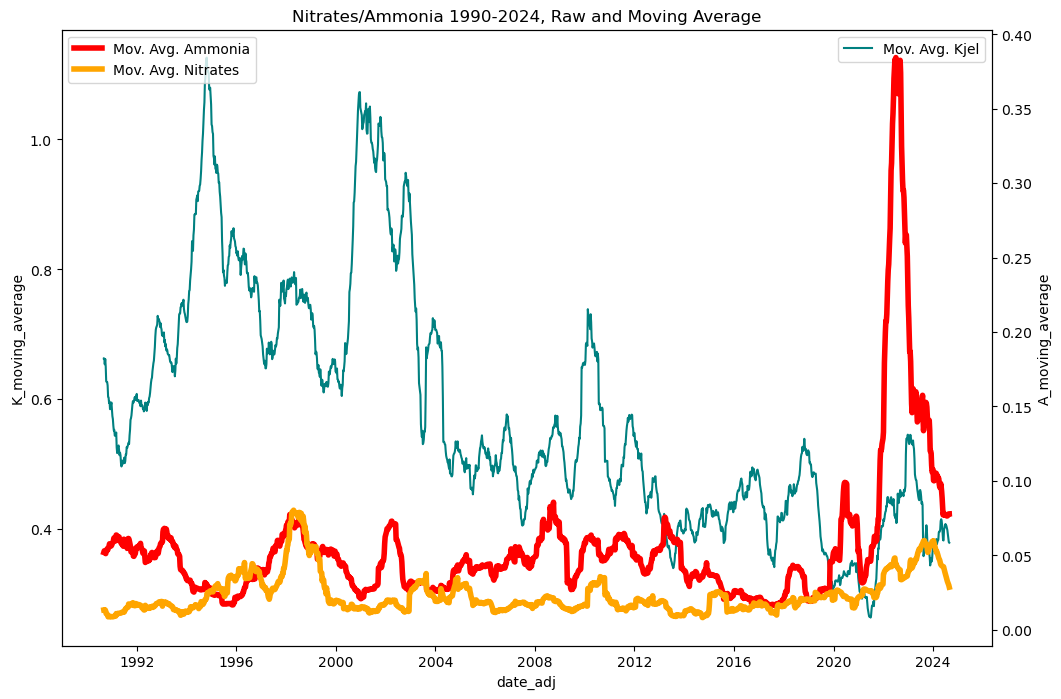

In [2408]:
fig,ax = plt.subplots(figsize=(12,8))
#sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_A,label='Raw Ammonia',color='black',lw=1,ax=ax)
ax1=ax.twinx()
#sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_N,label='Raw Nitrates',color='orange',lw=1,ax=ax1)
sns.lineplot(x=nmerge.index,y=nmerge.K_moving_average,label='Mov. Avg. Kjel',color='teal',ax=ax)
sns.lineplot(x=nmerge.index,y=nmerge.A_moving_average,label='Mov. Avg. Ammonia',color='red',lw=4,ax=ax1)
sns.lineplot(x=nmerge.index,y=nmerge.N_moving_average,label='Mov. Avg. Nitrates',color='orange',lw=4,ax=ax1)


plt.title('Nitrates/Ammonia 1990-2024, Raw and Moving Average')
plt.show()

__** This test was ultimately disregarded. Exported CSVs were imported in the NEKTON notebook for further processing **__

##### Nitrogen Loading Conclusions

Due to issues with formatting the datetime index, I haven't been able to get the frequency to set properly and, consequently, forecasting likely will be unhelpful. Results and conclusions drawn from the model should be understood with this in mind as it's difficult to assess the accuracy and performance of the model, particularly as a forecasting model. There are inferences that can be drawn about the relationships captured by the model between the 3 features.

The model had the most difficulty handling Nitrate values. P-values were less than 0.05 only in 4 lag iterations of the model - spiking beyond 0.45 in the next tier of 8 lags. The results do show, however, in the 4 and subsequent 8 lag iterations, nitrates has strong autocorrelation at the 4 week intervals (L1,L4,L8) which may provide insight into its sources. The 4 week lag period could be related to the transport time of nitrates through the watershed, which begins far inland before draining into the river systems and ultimately the bay. Monthly cyclicality of anthrogenic comunity services - such as agricultral practices, sewage treatment, would correlate  

There is some noted influence of ammonia on Kjeldahl values at lag 1 and lag 4, which could be explained by the conversion of organic nitrates into ammonia in the mineralisation process. The Kjelahl method also is measured as ammonia measured while processing water samples with a catalyst agent. Indirect influences of biological processes and existing levels of ammonia could explain this relationship; however, this is only one observation and not the primary driver of Kjeldahl concentrations or vice-versa.

Kjeldahl is more complex with of autocorrelation at lag 1,2,8,9, influences on ammonia at lag 1,2,4 and nitrogen  while also impacting ammonia at week 1,2,4, and nitro at possible 1 and 2; however, this does lend confidence to its use as a proxy as the organic form of nitrogen in the ecosystem. Decay and decomposition would impact ammonia and nitrate concentrations.

Low values of AIC and BIC are encouraging that the model performed reasonably well in explaining the existing data; however, no conclusions can be made about the model's predictive power without being rerun with corrected datasets and evaluation of its performance through error metrics.

I am confident though in proceeding with the base assumptions necessary to proceed its application in the development of the API (index).

### Development 99.206KM COASTLINE NOT INCLUDING WATERWAYS

Here is the introduction of construction, real estate and development influences on the bay.
It is difficult to retrieve consisten data for land usage, development and coastal construction, due to privacy rights, hidden data and more.

Possible methods:
- Aerial, geospatial analysis. Land use, development can be assessed through aerial imagery taken over time. With scale, images can be sectioned and assessed. This requires a great deal of effort to utilize specific geospatial data. This form  of investigation is covered by another notebook.
- Examination of land usage is a component but *can* require extensive work so it is being included here.
- Construction. Looking at permits, construction dates and even sales can inform development rates.

Based on data availability, this study chose to look at the construction date of individual parcels of land in coastal regions.

A critical concept to note is an understanding of how to describe coastal development and the underlying concepts, particularly in an estuarine system. Coastal contsruction should be evaluated by development around watersheds that feed into the main body of water. These have an equal weighted influence on anthropogenic pressures on the local marine ecosystem.

Data Description:

The CSVs read in below cover sections of the coastline and specifically attributes of individual plots of land. The primary features of interest are
- Property Acreage
- Year Built
- Number of structures built
- Land type
- Total square footage of structure

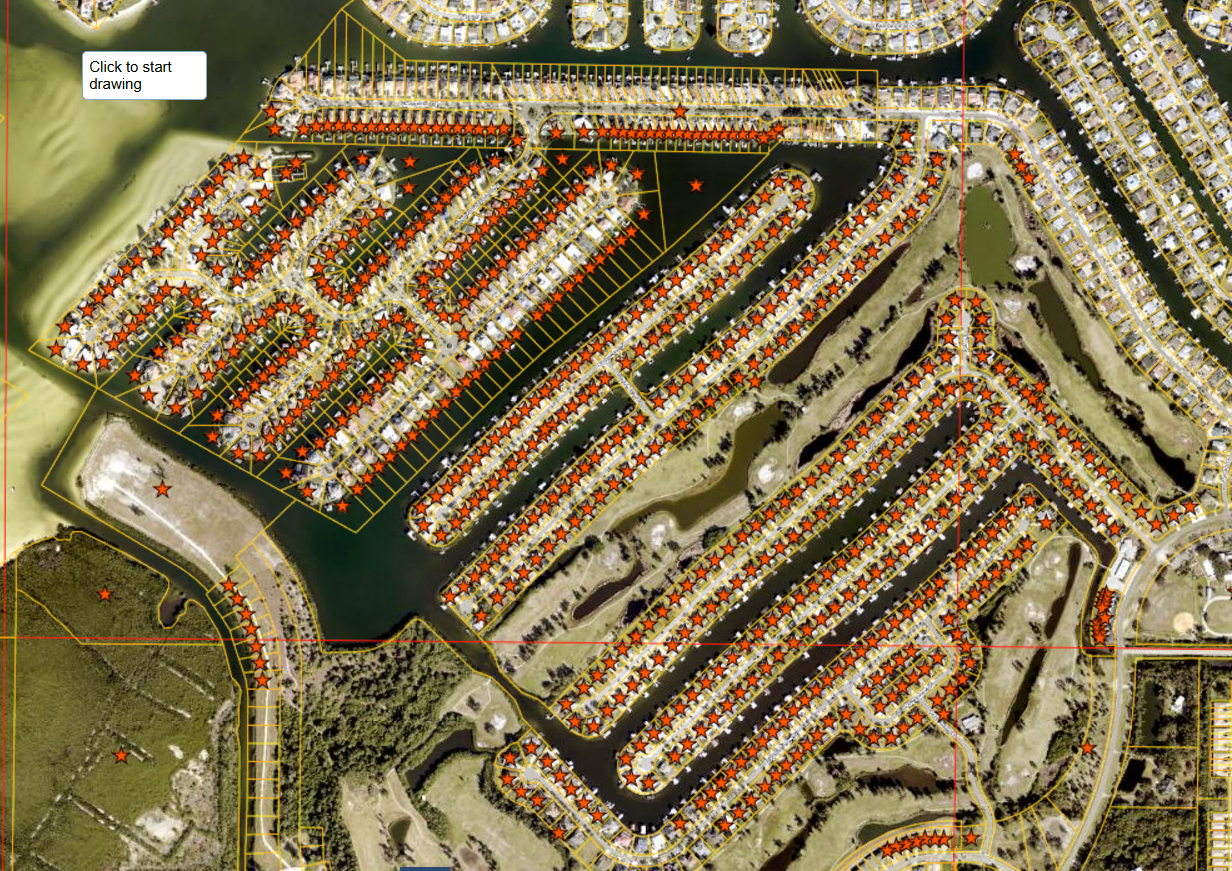

In [332]:
os.chdir('J:/Brainstation/BS Git/Property Records')

In [333]:
x=os.listdir()

In [334]:
AB_1=pd.read_csv('AB_1.csv')
AB_2=pd.read_csv('AB_BLVD_SPIT_1.csv')
AB_3=pd.read_csv('AB_Central_1.csv')
AB_4=pd.read_csv('AB_INTSXN_1.csv')
AB_5=pd.read_csv('AB_SOUTH_1.csv')
AB_6=pd.read_csv('AB_SOUTH_2.csv')
AB_7=pd.read_csv('AB_SPIT_1.csv')
GIB_8=pd.read_csv('GIB_MAIN_1.csv')

In [335]:
RIV_1=pd.read_csv('RIV_W_1.csv')

In [339]:
os.chdir('J:/Brainstation/BS Git/Property Records')

In [340]:
AB_1.head(2)

,Strap,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,LastSaleDate,LastSalePrice,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,YearBuilt,BldgCost,SqrFoot,HtdSqrFoot,Neighborhood,CensusTract,Lat,Lng
0,U-17-31-19-1T4-000000-00011.0,PARSONS AARON A,Y,1,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,10/10/2018 12:00:00 AM,504000.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022,3.0,3,5,1,1987,256523.0,3958,2882,227006,1.205701e+11,27.780714,-82.417778
1,U-18-32-19-ZZZ-000001-79190.0,RIVERSIDE MHP LLC,N,28,2814 - Parking lots commercial,3.01,1501 Susie Cir,Ruskin,33570.0,312 SAVANNAH OAKS PL,SEFFNER,FL,33584,682667.0,0.0,4/2/2021 12:00:00 AM,1095000.0,1382400.0,1382400.0,RSC-6,32S,18.0,19E,ZZZ,000001,79190.0,576610000,3.0,5,4,8,1966,80946.0,3826,3412,227001,1.205701e+11,27.703499,-82.446503


In [341]:
AB_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    1000 non-null   object 
 1   Folio                    1000 non-null   int64  
 2   PIN                      1000 non-null   object 
 3   PropertyType             912 non-null    object 
 4   Owner1                   1000 non-null   object 
 5   Owner2                   515 non-null    object 
 6   MailingAddress1          1000 non-null   object 
 7   MailingAddress2          33 non-null     object 
 8   MailingCity              999 non-null    object 
 9   MailingState             1000 non-null   object 
 10  MailingZip               994 non-null    object 
 11  MailingCountry           6 non-null      object 
 12  SiteAddress              971 non-null    object 
 13  SiteCity                 997 non-null    object 
 14  SiteZip                  

In [342]:
dflist=[
AB_1,
AB_2,
AB_3,
AB_4,
AB_5,
AB_6,
AB_7,
GIB_8,
RIV_1]

In [343]:
dfprop=pd.DataFrame(data=AB_2)

In [344]:
# Combine all sections of property data
# dfprop = 'Dataframe: Property'
for x in dflist:
    print(x.shape)
    dfprop=pd.concat([dfprop,x],axis=0)

(500, 39)
(1000, 45)
(1000, 45)
(121, 45)
(1000, 45)
(660, 45)
(505, 45)
(1000, 45)
(1000, 45)


In [345]:
dfprop1=dfprop.copy()

In [346]:
dfprop.head(5)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,1506200.0,1506200.0,0.0,0.0,0.0,0.0,1506200.0,1458728.0,1458728.0,2016-10-25,6720000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,33602-5600,NaN,6650 DICKMAN RD,APOLLO BEACH,33572.0,19.51,No,COM AT SE COR OF SEC 16 N 89 DEG 24 MIN 10 SEC...,0 FT N 00 DEG 32 MIN 38 SEC E 30 FT FOR POB N ...,EG 24 MIN 10 SEC W 1235.13 FT N 00 DEG 45 MIN ...,SEC E 702.42 FT N 88 DEG 48 MIN 46 SEC E 140.7...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,5.0,6.0,6.0,1.0,4.0,2014,528573.0,528573.0,3943661.0,214709.0,33167.0,59269.0,4686943.0,4570922.0,4570922.0,1973-01-01,100.0,NaN,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,NaN,NaN,NaN,APOLLO BEACH,33572.0,110.66,No,APOLLO BEACH SUB FLAMINGO CANAL AND OTHER CANA...,"B 34-41, PB 34-40, PB34-98, PB 35-41, PB 35-98...","44-90, PB 42-7, PB 37-79 SECTION 20, 21 AND 2...",-19,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,33602-3597,NaN,501 APOLLO BEACH BLVD,APOLLO BEACH,33572.0,14.82,No,RUSKIN TOMATO FARMS THAT PT OF TRS 20 & 27 DES...,BEG 261.88 FT S & 50 FT W OF NE COR OR NE 1/4...,UN S 1123.15 FT TO N BDRY OF APOLLO BEACH BLVD...,81.15 FT N 1125.33 FT AND E 581.15 FT TO BEG,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,1981,3386382.0,3386382.0,12909615.0,443031.0,93256.0,93256.0,16739028.0,8986443.0,0.0,1980-07-01,33000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,504 ELSBERRY RD,APOLLO BEACH,33572.0,0.17,No,RUSKIN TOMATO FARMS W 71 FT OF E 91 FT OF N 10...,OF LOT 20,NaN,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0

In [347]:
dfprop.shape

(7786, 79)

In [348]:
AB_1.head(1)

,Strap,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,LastSaleDate,LastSalePrice,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,YearBuilt,BldgCost,SqrFoot,HtdSqrFoot,Neighborhood,CensusTract,Lat,Lng
0,U-17-31-19-1T4-000000-00011.0,PARSONS AARON A,Y,1,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,10/10/2018 12:00:00 AM,504000.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022,3.0,3,5,1,1987,256523.0,3958,2882,227006,1.205701e+11,27.780714,-82.417778


In [349]:
AB_2.head(1)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,1931151SF000000009000U,515550000,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0,0.0,0.0,0.0,0.0,0,1506200,1506200,0,0,0,0,1506200,1458728,1458728,2016-10-25,6720000,Vacant,Unqualified,NaN


In [350]:
AB_3.head(3)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,193109ZZZ000001736500U,514610000,U-09-31-19-ZZZ-000001-73650.0,PREFAB MTL BLD,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,33601-0111,NaN,603 BIG BEND RD,GIBSONTON,33534,416.07,No,9 AND 10 31 19 FRAC N 1/2 SEC 9 AND WLY EXT TH...,F DESC AS BEG AT INTERS OF E AND W 1/4 LINE WI...,SEC BDRY AND RUN W ALONG 1/4 SEC LINE AND ITS...,EXT 3960 FT N 2636.19 FT TO PT ON WLY PROJECT...,UNPLATTED,Gibsonton Area S of River,UNINCORPORATED,U,38,167.0,50.0,0.0,0.0,1985,12773011,12773011,31474408,10257988,593167,624374,54505407,54505407,54505407,1981-12-01,100,NaN,Unqualified,NaN
1,193114ZZZ000001743500U,515310000,U-14-31-19-ZZZ-000001-74350.0,WRHSE DISTRIB,FUTERNICK ASSOCIATES,NaN,1430 S DIXIE HWY UNIT 1226,NaN,CORAL GABLES,FL,33146-3176,NaN,6861N 41 HWY,APOLLO BEACH,33572-,13.92,No,THAT PART OF NW 1/4 OF SW 1/4 DESC AS : BEG AT...,ER OF WLY R/W LINE OF ACL RR AND E BDRY LINE O...,23 AND RUN N 28 DEG 36 MIN 28 SEC E ALONG RR ...,.75 FT N 89 DEG 32 MIN 36 SEC W 704.83 FT N 84...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,2,2.0,2.0,0.0,0.0,2019,1688906,1688906,9551460,623000,86761,91823,7578800,7578800,7578800,2017-08-25,2662500,Vacant,Unqualified,NaN
2,1931151SF000000003000U,515410000,U-15-31-19-1SF-000000-00300.0,SERVICE/REPAIR SHOP,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,33601-0111,NaN,490 BIG BEND RD,APOLLO BEACH,33572,136.96,No,RUSKIN TOMATO FARMS LOT 3 LESS E 450 FT AND LE...,90 FT ... LOT 4 LESS N 90 FT ... LOT 6 LESS N...,FT OF E 450 FT ... LOT 7,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1,0.0,1.0,0.0,0.0,1960,5868642,5868642,78204,31098,4071,4071,5977944,5977944,5977944,1982-02-01,430500,Improved,Unqualified,NaN


In [351]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7786 entries, 0 to 999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    7786 non-null   object 
 1   Folio                    7286 non-null   float64
 2   PIN                      7286 non-null   object 
 3   PropertyType             6229 non-null   object 
 4   Owner1                   7286 non-null   object 
 5   Owner2                   3635 non-null   object 
 6   MailingAddress1          7286 non-null   object 
 7   MailingAddress2          331 non-null    object 
 8   MailingCity              7280 non-null   object 
 9   MailingState             7286 non-null   object 
 10  MailingZip               7248 non-null   object 
 11  MailingCountry           41 non-null     object 
 12  SiteAddress              6990 non-null   object 
 13  SiteCity                 7261 non-null   object 
 14  SiteZip                  7258 

In [352]:
"""
Columns for Selection Pressure analysis

3,
8,
14,
15,
25,
26,
30,
36,
40,
42

"""

'\nColumns for Selection Pressure analysis\n\n3,\n8,\n14,\n15,\n25,\n26,\n30,\n36,\n40,\n42\n\n'

In [353]:
dfprop.drop_duplicates(inplace=True)

In [354]:
dfprop=dfprop[dfprop.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [355]:
RIV_1=RIV_1[RIV_1.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [356]:
RIV_1.shape

(1000, 11)

In [357]:
dfprop.shape

(6358, 11)

In [358]:
dfprop1

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,1506200.0,1506200.0,0.0,0.0,0.0,0.0,1506200.0,1458728.0,1458728.0,2016-10-25,6720000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,33602-5600,NaN,6650 DICKMAN RD,APOLLO BEACH,33572.0,19.51,No,COM AT SE COR OF SEC 16 N 89 DEG 24 MIN 10 SEC...,0 FT N 00 DEG 32 MIN 38 SEC E 30 FT FOR POB N ...,EG 24 MIN 10 SEC W 1235.13 FT N 00 DEG 45 MIN ...,SEC E 702.42 FT N 88 DEG 48 MIN 46 SEC E 140.7...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,5.0,6.0,6.0,1.0,4.0,2014,528573.0,528573.0,3943661.0,214709.0,33167.0,59269.0,4686943.0,4570922.0,4570922.0,1973-01-01,100.0,NaN,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,NaN,NaN,NaN,APOLLO BEACH,33572.0,110.66,No,APOLLO BEACH SUB FLAMINGO CANAL AND OTHER CANA...,"B 34-41, PB 34-40, PB34-98, PB 35-41, PB 35-98...","44-90, PB 42-7, PB 37-79 SECTION 20, 21 AND 2...",-19,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,33602-3597,NaN,501 APOLLO BEACH BLVD,APOLLO BEACH,33572.0,14.82,No,RUSKIN TOMATO FARMS THAT PT OF TRS 20 & 27 DES...,BEG 261.88 FT S & 50 FT W OF NE COR OR NE 1/4...,UN S 1123.15 FT TO N BDRY OF APOLLO BEACH BLVD...,81.15 FT N 1125.33 FT AND E 581.15 FT TO BEG,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,1981,3386382.0,3386382.0,12909615.0,443031.0,93256.0,93256.0,16739028.0,8986443.0,0.0,1980-07-01,33000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,504 ELSBERRY RD,APOLLO BEACH,33572.0,0.17,No,RUSKIN TOMATO FARMS W 71 FT OF E 91 FT OF N 10...,OF LOT 20,NaN,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0

In [359]:
dfprop=pd.concat([dfprop,RIV_1])

In [360]:
dfprop.isna().sum()

Strap                    0
PropertyType          1676
SiteCity               522
SiteZip                523
Acreage                500
TotalNumBuildings      500
TotalStories           500
YearBuilt                0
TotalGrossAreaSqFt     500
LastSaleDate           164
VacantImproved         818
dtype: int64

In [361]:
# To be consildated into higher aggregate categories: Residential, Commercial, Industrial, Other
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     3514
MANUFACTURED HOME (AYB > 1976)     722
TOWNHOUSE                          604
MOBILE HOME (AYB < 1977)           258
CONDOMINIUM                        149
OFFICE <3 STORY                     65
PREFAB MTL BLD                      54
WRHSE - STORAGE                     42
DUPLEX/TRIPLEX/QUADPLX/ETC          39
COMM/CONDO 2                        30
AUTO SERVICE/REPAIR GARAGE          24
NOT CALCULATING                     20
CLUBHOUSE                           18
RETAIL STRIP CENTER                 18
WRHSE DISTRIB                       13
CONVENIENCE STORE                   12
STORE RETAIL                        12
MODULAR HOME                        11
APARTMENT <4 STORY                   9
MFG LIGHT                            9
CHURCH                               8
SERVICE/REPAIR SHOP                  7
RESTAURANT                           6
MEDICAL OFFICE                       5
SCHOOL                               4
REST FAST FO

In [362]:
# Slight cleaning of the data
# Some of the grids overlapped so these rows must be accounted for
dfprop.duplicated().value_counts()

False    6358
True     1000
Name: count, dtype: int64

In [363]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7358 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Strap               7358 non-null   object 
 1   PropertyType        5682 non-null   object 
 2   SiteCity            6836 non-null   object 
 3   SiteZip             6835 non-null   object 
 4   Acreage             6858 non-null   float64
 5   TotalNumBuildings   6858 non-null   float64
 6   TotalStories        6858 non-null   float64
 7   YearBuilt           7358 non-null   int64  
 8   TotalGrossAreaSqFt  6858 non-null   float64
 9   LastSaleDate        7194 non-null   object 
 10  VacantImproved      6540 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 689.8+ KB


In [364]:
dfprop.isna().sum()

Strap                    0
PropertyType          1676
SiteCity               522
SiteZip                523
Acreage                500
TotalNumBuildings      500
TotalStories           500
YearBuilt                0
TotalGrossAreaSqFt     500
LastSaleDate           164
VacantImproved         818
dtype: int64

In [365]:
dfprop.Acreage

0       41.89
1       19.51
2      110.66
3       14.82
4        0.17
        ...  
995      0.21
996      0.59
997      5.28
998      0.84
999    427.38
Name: Acreage, Length: 7358, dtype: float64

In [366]:
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     3514
MANUFACTURED HOME (AYB > 1976)     722
TOWNHOUSE                          604
MOBILE HOME (AYB < 1977)           258
CONDOMINIUM                        149
OFFICE <3 STORY                     65
PREFAB MTL BLD                      54
WRHSE - STORAGE                     42
DUPLEX/TRIPLEX/QUADPLX/ETC          39
COMM/CONDO 2                        30
AUTO SERVICE/REPAIR GARAGE          24
NOT CALCULATING                     20
CLUBHOUSE                           18
RETAIL STRIP CENTER                 18
WRHSE DISTRIB                       13
CONVENIENCE STORE                   12
STORE RETAIL                        12
MODULAR HOME                        11
APARTMENT <4 STORY                   9
MFG LIGHT                            9
CHURCH                               8
SERVICE/REPAIR SHOP                  7
RESTAURANT                           6
MEDICAL OFFICE                       5
SCHOOL                               4
REST FAST FO

In [367]:
dfprop.PropertyType.isna().sum()

1676

In [368]:
dfprop.PropertyType.fillna('undefined',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\2890697567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfprop.PropertyType.fillna('undefined',inplace=True)


In [369]:
dfprop.duplicated().sum()

1000

In [370]:
# Get rid of redundant data rows|
dfprop.drop_duplicates(inplace=True)

In [371]:
dfprop.isna().sum()

Strap                   0
PropertyType            0
SiteCity              517
SiteZip               518
Acreage               500
TotalNumBuildings     500
TotalStories          500
YearBuilt               0
TotalGrossAreaSqFt    500
LastSaleDate          101
VacantImproved        710
dtype: int64

In [372]:
dfprop.duplicated().value_counts()

False    6358
Name: count, dtype: int64

In [373]:
dfprop[dfprop.SiteCity.isna()==True]

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
994,193122C6N000000000010U,REST FAST FOOD,NaN,NaN,0.84,1.0,1.0,2021,2814.0,2022-03-15,Improved
995,193122C6N000000000020U,MEDICAL OFFICE,NaN,NaN,0.70,1.0,1.0,2021,4830.0,2021-12-16,Improved
996,193122C6N000000000030U,MEDICAL OFFICE,NaN,NaN,0.69,1.0,1.0,2021,4620.0,2020-10-02,Vacant
0,U-17-31-19-1T4-000000-00011.0,undefined,NaN,NaN,NaN,NaN,NaN,1987,NaN,10/10/2018 12:00:00 AM,NaN
1,U-18-32-19-ZZZ-000001-79190.0,undefined,NaN,NaN,NaN,NaN,NaN,1966,NaN,4/2/2021 12:00:00 AM,NaN
...,...,...,...,...,...,...,...,...,...,...,...
404,192922ZZZ000001494603U,undefined,NaN,NaN,0.20,0.0,0.0,0,0.0,2023-05-23,Vacant
405,192922ZZZ000001494605U,undefined,NaN,NaN,0.15,0.0,0.0,0,0.0,2023-05-23,Vacant
406,192922ZZZ000001494607U,undefined,NaN,NaN,0.17,0.0,0.0,0,0.0,2023-05-23,Vacant
583,192927663000001589701U,undefined,NaN,NaN,2.71,0.0,0.0,0,0.0,2022-03-31,Vacant


In [374]:
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0]

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
35,1931211TM000001000220U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.24,1.0,1.0,1977,2149.0,2002-03-22,NaN
85,1931211TM000006000090U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.23,1.0,1.0,1959,2194.0,2001-12-18,NaN
113,1931211TM000017000280U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.18,1.0,1.0,1971,1400.0,2001-01-10,NaN
115,1931211TM000017000300U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.18,1.0,1.0,1971,1868.0,2002-04-16,NaN
0,U-17-31-19-1T4-000000-00011.0,undefined,NaN,NaN,NaN,NaN,NaN,1987,NaN,10/10/2018 12:00:00 AM,NaN
...,...,...,...,...,...,...,...,...,...,...,...
895,193003663000001671901U,WRHSE DISTRIB,TAMPA,33619,99.01,1.0,1.0,2009,591898.0,NaN,NaN
910,193004ZZZ000001672102U,PREFAB MTL BLD,TAMPA,33619,12.12,3.0,3.0,2007,4582.0,NaN,NaN
915,193004ZZZ000001672300U,MANUFACTURED HOME (AYB > 1976),TAMPA,33619,3.75,1.0,1.0,1987,1348.0,NaN,NaN
932,193005ZZZ000005818120U,PREFAB MTL BLD,TAMPA,33619,15.00,3.0,3.0,1993,2613.0,NaN,NaN


In [375]:
# not all columns are relevant and their NaN, null or 0 status is not important
dfprop.isna().sum()

Strap                   0
PropertyType            0
SiteCity              517
SiteZip               518
Acreage               500
TotalNumBuildings     500
TotalStories          500
YearBuilt               0
TotalGrossAreaSqFt    500
LastSaleDate          101
VacantImproved        710
dtype: int64

In [376]:
# Improved plots that have been misclassified
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\1555862745.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)


In [377]:
# Looking for common traits - perhaps it speaks to why these properties were misclassified and and relevance
dfprop[dfprop.YearBuilt==0].PropertyType.unique()

array(['undefined', 'CONDOMINIUM', 'TOWNHOUSE'], dtype=object)

In [381]:
dfprop

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
0,1931151SF000000009000U,undefined,APOLLO BEACH,33572.0,41.89,0.0,0.0,0,0.0,2016-10-25,Vacant
1,193116ZZZ000001745900U,MANUFACTURED HOME (AYB > 1976),APOLLO BEACH,33572.0,19.51,5.0,6.0,2014,59269.0,1973-01-01,NaN
2,193120ZZZ000001751101U,undefined,APOLLO BEACH,33572.0,110.66,0.0,0.0,0,0.0,NaN,NaN
3,1931211SF000000560000U,SCHOOL,APOLLO BEACH,33572.0,14.82,1.0,1.0,1981,93256.0,1980-07-01,Vacant
4,1931211SF000000562002U,undefined,APOLLO BEACH,33572.0,0.17,0.0,0.0,0,0.0,2013-02-18,Vacant
...,...,...,...,...,...,...,...,...,...,...,...
991,1930231R100000000007IU,MOBILE HOME (AYB < 1977),RIVERVIEW,33578,0.14,1.0,1.0,1971,1200.0,2022-07-21,Improved
992,1930231R100000000007JU,MANUFACTURED HOME (AYB > 1976),RIVERVIEW,33578,0.14,1.0,1.0,1983,1442.0,2018-04-11,Improved
993,1930231R1000000000081U,SINGLE FAMILY,RIVERVIEW,33578,0.36,2.0,2.0,1986,4747.0,1994-10-01,Improved
994,1930231R1000000000086U,SINGLE FAMILY,RIVERVIEW,33578,0.42,1.0,1.0,2021,1310.0,1977-09-01,Improved


In [387]:
dfprop.sort_values(by='YearBuilt').YearBuilt.value_counts().sort_index()

YearBuilt
0       1088
1900       1
1902       1
1911       1
1919       1
        ... 
2020      41
2021      51
2022      85
2023     115
2024      93
Name: count, Length: 104, dtype: int64

Primary features of interest for simple model are Year Built, Acreage, totalGrossAreaSqft.

Understanding the relationship between development per property and population density and growth will be a calculated feature used in the construction of the HII-aquatic index.

### Housing, Population Density and Change

The impact of coastal development extends beyond the shoreline. In an estuarine environment, the watersheds that feed into the estuary (or in the case the bay) are equally important. Using a highway as a physical boundary overlapped with a map of the various watersheds, a representative set of properties, the type, their acreage and the year that they were built will be used as an estimate and proxy for coastline development.  Based on research literature, concentration of non-organic nitrates and phosphates will serve as a proxy for the introduction of artificial damaging compounds - however, in the construction of more complex models, more granular data can be used.

In [378]:
## New Construction estimates by year

In [403]:
dfprop.head(1)

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
0,1931151SF000000009000U,undefined,APOLLO BEACH,33572.0,41.89,0.0,0.0,0,0.0,2016-10-25,Vacant


In [404]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6358 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Strap               6358 non-null   object 
 1   PropertyType        6358 non-null   object 
 2   SiteCity            5841 non-null   object 
 3   SiteZip             5840 non-null   object 
 4   Acreage             5858 non-null   float64
 5   TotalNumBuildings   5858 non-null   float64
 6   TotalStories        5858 non-null   float64
 7   YearBuilt           6358 non-null   int64  
 8   TotalGrossAreaSqFt  5858 non-null   float64
 9   LastSaleDate        6257 non-null   object 
 10  VacantImproved      5648 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 596.1+ KB


In [405]:
dfyearbuilt=dfprop[dfprop.YearBuilt>1988].groupby('YearBuilt').YearBuilt.count()

In [437]:
dfacreage=dfprop[dfprop.YearBuilt>1988].groupby('YearBuilt').Acreage.sum()

In [439]:
dfacreage

YearBuilt
1989     51.58
1990    213.29
1991     18.95
1992     27.18
1993    977.22
1994     46.85
1995     37.03
1996     49.08
1997     31.53
1998     58.90
1999     45.05
2000     70.58
2001     27.78
2002     58.55
2003     79.41
2004     80.98
2005     51.38
2006     76.47
2007     99.96
2008     34.45
2009    160.56
2010     15.96
2011     39.24
2012      1.61
2013      8.15
2014     48.94
2015     22.31
2016      6.16
2017     25.03
2018     14.23
2019     43.59
2020     17.04
2021     83.83
2022     26.23
2023     19.72
2024     10.42
Name: Acreage, dtype: float64

In [406]:
dfyearbuilt

YearBuilt
1989     74
1990     68
1991     43
1992     68
1993     92
1994     69
1995    107
1996    120
1997     81
1998    105
1999     90
2000     95
2001     75
2002     95
2003     81
2004    163
2005    287
2006    254
2007    205
2008     66
2009     25
2010     29
2011     26
2012     20
2013     48
2014     56
2015     64
2016     23
2017     26
2018     36
2019     34
2020     41
2021     51
2022     85
2023    115
2024     93
Name: YearBuilt, dtype: int64

In [407]:
len(dfyearbuilt)

36

In [408]:
# Get annual change of homes built on hillsborough bay coast from 1990-present
perchange=[]
year=1989
year1=[]
x_base=[]
x1=[]
for x in range(1989,1989+len(dfyearbuilt)):
    if x==0:
        continue
    elif x==1988+len(dfyearbuilt):
        break
    else:
        perchange.append(round((dfyearbuilt[x+1]/dfyearbuilt[x])*100,3))
        x_base.append(dfyearbuilt[x])
        x1.append(dfyearbuilt[x+1])
    year+=1
    year1.append(year)

In [409]:
perchange[0:5]

[91.892, 63.235, 158.14, 135.294, 75.0]

In [410]:
dfperchange=pd.DataFrame()
dfperchange['percentchange']=perchange

In [411]:
dfperchange['x']=x_base
dfperchange['x+1']=x1
dfperchange['year']=year1

In [412]:
dfperchange.head(5)

,percentchange,x,x+1,year
0,91.892,74,68,1990
1,63.235,68,43,1991
2,158.140,43,68,1992
3,135.294,68,92,1993
4,75.000,92,69,1994


In [413]:
dfprop.LastSaleDate=pd.to_datetime(dfprop.LastSaleDate)

ValueError: time data "10/10/2018 12:00:00 AM" doesn't match format "%Y-%m-%d", at position 1000. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [414]:
dfperchange=pd.concat([dfperchange,dfperchange_unit.iloc[:,0:3]],axis=1)

NameError: name 'dfperchange_unit' is not defined

In [415]:
dfprop[dfprop.YearBuilt>1989].groupby(['YearBuilt']).TotalNumBuildings.agg(['min', 'max', 'std', 'sum'])

,min,max,std,sum
YearBuilt,,,,
1990,1.0,4.0,0.443977,70.0
1991,1.0,2.0,0.152499,44.0
1992,1.0,1.0,0.000000,64.0
1993,1.0,7.0,0.929039,104.0
1994,1.0,1.0,0.000000,69.0
1995,1.0,1.0,0.000000,103.0
1996,1.0,2.0,0.130734,118.0
1997,1.0,2.0,0.115470,76.0
1998,1.0,3.0,0.294418,107.0


In [441]:
dfacreage

YearBuilt
1989     51.58
1990    213.29
1991     18.95
1992     27.18
1993    977.22
1994     46.85
1995     37.03
1996     49.08
1997     31.53
1998     58.90
1999     45.05
2000     70.58
2001     27.78
2002     58.55
2003     79.41
2004     80.98
2005     51.38
2006     76.47
2007     99.96
2008     34.45
2009    160.56
2010     15.96
2011     39.24
2012      1.61
2013      8.15
2014     48.94
2015     22.31
2016      6.16
2017     25.03
2018     14.23
2019     43.59
2020     17.04
2021     83.83
2022     26.23
2023     19.72
2024     10.42
Name: Acreage, dtype: float64

In [417]:
# Get annual change of Total buildings built on hillsborough bay coast from 1990-present
perchange_build=[]
year_build=1989
year1_build=[]
x_base1=[]
x2=[]
for x in range(1989,1989+len(dftotalunit)):
    if x==0:
        continue
    elif x==1988+len(dfyearbuilt):
        break
    else:
        perchange_build.append(round((dftotalunit[x+1]/dftotalunit[x])*100,3))
        x_base1.append(dftotalunit[x])
        x2.append(dftotalunit[x+1])
    year_build+=1
    year1_build.append(year_build)

NameError: name 'dftotalunit' is not defined

In [418]:
# Describes number of houses built in subset data, total number of units per built structure
# Multi-unit buildings have an increased environmental impact per individual parcel
dfperchange_unit

NameError: name 'dfperchange_unit' is not defined

In [419]:
##### Population

In [420]:
os.chdir('J:\\Brainstation\\Capstone Git')

In [421]:
dftraffic=pd.read_csv('MaritimeTraffic_TB.csv')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\3424837237.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  dftraffic=pd.read_csv('MaritimeTraffic_TB.csv')


In [422]:
##### Current Working Space
## Maritime Traffic may not be taken into consideration, although it certainly plays a role in ecosystem health.
## As the final index will be created as an aggregate index, it can be assess and introduced into the model once created.
## This data presents a problem as it only describes docking behavior - not the passage of the ship's trip.

In [423]:
os.chdir('J:\\Brainstation\\BS Git\\data\\human Imact\\MarineTraffic')

In [424]:
### Looking into population statistics nolw

In [425]:
dfpop_staged=pd.read_csv('StagedPopulations.csv')

In [426]:
dfpop=pd.DataFrame()
dfpop['year']=0
dfpop['sumpop']=0

In [427]:
dfpop_staged.iloc[:,1]

0     12407
1    101040
2    101047
3    101054
4    101064
Name: OBJECTID, dtype: int64

In [428]:
dfpop_staged
## This file was originally a geodatabase file that has been read in as a CSV to access the non-geospatial data.

,wkt_geom,OBJECTID,SMOD_LEVEL,SMOD_ID,ISO,CNTRY_NAME,JRC_NAME_MAIN,JRC_NAME_LIST,CIESIN_NAME,CIESIN_NAME_TL,AREA_SQKM,AREA_SQM,CIESIN_NAME_ADJ,ADJ,GHSPOP_R19_1975,GHSPOP_R19_1990,GHSPOP_R19_2000,GHSPOP_R19_2015,GHSPOP_R23_1975,GHSPOP_R23_1980,GHSPOP_R23_1985,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025,GHSPOP_R23_2030
0,MultiPolygon (((-82.72100607199996603 28.37449...,12407,30,30_12407,USA,United States,Tampa,Tampa; Saint Petersburg; Clearwater; Brandon; ...,Tampa,Tampa,1745.422402,1.745422e+09,Tampa,0.0,F,1.305016e+06,1.714504e+06,1.993365e+06,980167.207100,1.195809e+06,1.333843e+06,1.480168e+06,1.601766e+06,1.717621e+06,1.824984e+06,1.920968e+06,2.045045e+06,2.191664e+06,2.261370e+06,2.330530e+06
1,MultiPolygon (((-82.41634709599998132 27.71290...,101040,23,23_87924,USA,United States,Sun City Center,Sun City Center; Greater Sun Center; Ruskin; G...,"Greater Sun Center, Sun City Center","Greater Sun Center, Sun City Center",42.796333,4.279633e+07,"Greater Sun Center, Sun City Center",NaN,11163.29545,1.725212e+04,2.122397e+04,2.838951e+04,12661.218560,1.253746e+04,1.568739e+04,1.837320e+04,2.062473e+04,2.210739e+04,2.713719e+04,2.711277e+04,2.903848e+04,3.109123e+04,3.220606e+04,3.357573e+04
2,MultiPolygon (((-82.37805279399998426 27.81459...,101047,23,23_87931,USA,United States,Adamsville,Adamsville; North Ruskin; Apollo Beach,Apollo Beach,Apollo Beach,26.476118,2.647612e+07,Apollo Beach,NaN,5564.827307,8.602107e+03,1.090787e+04,1.474059e+04,6259.350004,6.348697e+03,7.839934e+03,9.115709e+03,1.024629e+04,1.101930e+04,1.340539e+04,1.364281e+04,1.467739e+04,1.571192e+04,1.632053e+04,1.699778e+04
3,MultiPolygon (((-82.33898157599998058 27.82306...,101054,23,23_87938,USA,United States,Riverview,Riverview; Riverview,Panther Trace,Panther Trace,17.931987,1.793199e+07,Panther Trace,NaN,10059.89708,1.549627e+04,1.960960e+04,2.584830e+04,10124.148230,1.236164e+04,1.382634e+04,1.547221e+04,1.716790e+04,1.918479e+04,2.176125e+04,2.414159e+04,2.630752e+04,2.811921e+04,2.902663e+04,2.993258e+04
4,MultiPolygon (((-82.21098576599996477 27.84849...,101064,23,23_87948,USA,United States,Fishhawk,Fishhawk,Parkside Village,Parkside Village,4.980987,4.980987e+06,Parkside Village,NaN,2865.958633,4.492428e+03,5.881465e+03,7.213995e+03,3046.078571,3.750538e+03,4.166395e+03,4.651319e+03,5.197914e+03,5.798763e+03,6.694678e+03,7.502811e+03,8.249881e+03,8.864453e+03,9.098630e+03,9.350476e+03


In [435]:
dfpop_staged

,wkt_geom,OBJECTID,SMOD_LEVEL,SMOD_ID,ISO,CNTRY_NAME,JRC_NAME_MAIN,JRC_NAME_LIST,CIESIN_NAME,CIESIN_NAME_TL,AREA_SQKM,AREA_SQM,CIESIN_NAME_ADJ,ADJ,GHSPOP_R19_1975,GHSPOP_R19_1990,GHSPOP_R19_2000,GHSPOP_R19_2015,GHSPOP_R23_1975,GHSPOP_R23_1980,GHSPOP_R23_1985,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025,GHSPOP_R23_2030
0,MultiPolygon (((-82.72100607199996603 28.37449...,12407,30,30_12407,USA,United States,Tampa,Tampa; Saint Petersburg; Clearwater; Brandon; ...,Tampa,Tampa,1745.422402,1.745422e+09,Tampa,0.0,F,1.305016e+06,1.714504e+06,1.993365e+06,980167.207100,1.195809e+06,1.333843e+06,1.480168e+06,1.601766e+06,1.717621e+06,1.824984e+06,1.920968e+06,2.045045e+06,2.191664e+06,2.261370e+06,2.330530e+06
1,MultiPolygon (((-82.41634709599998132 27.71290...,101040,23,23_87924,USA,United States,Sun City Center,Sun City Center; Greater Sun Center; Ruskin; G...,"Greater Sun Center, Sun City Center","Greater Sun Center, Sun City Center",42.796333,4.279633e+07,"Greater Sun Center, Sun City Center",NaN,11163.29545,1.725212e+04,2.122397e+04,2.838951e+04,12661.218560,1.253746e+04,1.568739e+04,1.837320e+04,2.062473e+04,2.210739e+04,2.713719e+04,2.711277e+04,2.903848e+04,3.109123e+04,3.220606e+04,3.357573e+04
2,MultiPolygon (((-82.37805279399998426 27.81459...,101047,23,23_87931,USA,United States,Adamsville,Adamsville; North Ruskin; Apollo Beach,Apollo Beach,Apollo Beach,26.476118,2.647612e+07,Apollo Beach,NaN,5564.827307,8.602107e+03,1.090787e+04,1.474059e+04,6259.350004,6.348697e+03,7.839934e+03,9.115709e+03,1.024629e+04,1.101930e+04,1.340539e+04,1.364281e+04,1.467739e+04,1.571192e+04,1.632053e+04,1.699778e+04
3,MultiPolygon (((-82.33898157599998058 27.82306...,101054,23,23_87938,USA,United States,Riverview,Riverview; Riverview,Panther Trace,Panther Trace,17.931987,1.793199e+07,Panther Trace,NaN,10059.89708,1.549627e+04,1.960960e+04,2.584830e+04,10124.148230,1.236164e+04,1.382634e+04,1.547221e+04,1.716790e+04,1.918479e+04,2.176125e+04,2.414159e+04,2.630752e+04,2.811921e+04,2.902663e+04,2.993258e+04
4,MultiPolygon (((-82.21098576599996477 27.84849...,101064,23,23_87948,USA,United States,Fishhawk,Fishhawk,Parkside Village,Parkside Village,4.980987,4.980987e+06,Parkside Village,NaN,2865.958633,4.492428e+03,5.881465e+03,7.213995e+03,3046.078571,3.750538e+03,4.166395e+03,4.651319e+03,5.197914e+03,5.798763e+03,6.694678e+03,7.502811e+03,8.249881e+03,8.864453e+03,9.098630e+03,9.350476e+03


In [429]:
dfpop_staged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   wkt_geom         5 non-null      object 
 1   OBJECTID         5 non-null      int64  
 2   SMOD_LEVEL       5 non-null      int64  
 3   SMOD_ID          5 non-null      object 
 4   ISO              5 non-null      object 
 5   CNTRY_NAME       5 non-null      object 
 6   JRC_NAME_MAIN    5 non-null      object 
 7   JRC_NAME_LIST    5 non-null      object 
 8   CIESIN_NAME      5 non-null      object 
 9   CIESIN_NAME_TL   5 non-null      object 
 10  AREA_SQKM        5 non-null      float64
 11  AREA_SQM         5 non-null      float64
 12  CIESIN_NAME_ADJ  5 non-null      object 
 13  ADJ              1 non-null      float64
 14  GHSPOP_R19_1975  5 non-null      object 
 15  GHSPOP_R19_1990  5 non-null      float64
 16  GHSPOP_R19_2000  5 non-null      float64
 17  GHSPOP_R19_2015  5 n

In [430]:
nont=dfpop_staged.iloc[1:,21:29]

In [431]:
area=sum(dfpop_staged.iloc[1:,10])

In [432]:
f=pd.Series()
counter=1990
for x in nont.columns:
    f[counter]=sum(nont[x])
    counter+=5

In [433]:
f=f.to_frame().reset_index()

In [434]:
f[0]/area

0    516.485555
1    577.497249
2    630.362551
3    748.475240
4    785.373421
5    849.085035
6    908.894333
7    939.973460
Name: 0, dtype: float64

In [ ]:
fig,ax=plt.subplots(figsize=(10,10))
sns.lineplot(x=f.iloc[:,0],y=population_density,ax=ax)
plt.xlabel('Year')
plt.ylabel('Population Density (')
plt.title('Population Density from 1990-2024')

In [ ]:
ZZZ

In [ ]:
pwd

In [ ]:
os.chdir('J:\Brainstation\BS Git\human Imact\MarineTraffic')

In [ ]:
os.chdir('J:\\Brainstation\\BS Git\\human Imact\\MarineTraffic')

In [ ]:
dem = pd.read_csv('dfdemographics.csv')

In [ ]:
dem

In [ ]:
plt.figure(figsize=10,10)
sns.lineplot(x='year',y='percentchange',data=dem,label='Change in contruction rate')